# Sentence Memorability: Experimental Analysis

## Background & Research Context

This notebook presents a comprehensive analysis of a **continuous recognition memory experiment** investigating how sentence memorability is affected by the memorability of constituent words and syntactic voice.

### Relevant Literature
- **Shepard (1967)** — Recognition memory for words, sentences, and pictures ([link](https://www.sciencedirect.com/science/article/abs/pii/S0022537171800105))
- **Begg & Paivio (1969)** — Concreteness and imagery in sentence meaning ([link](https://www.sciencedirect.com/science/article/abs/pii/S0022537168800222))
- **Brockway, Chmielewski & Cofer (1974)** — Remembering prose ([link](https://www.sciencedirect.com/science/article/abs/pii/S002253717380060X))

### Experiment Summary
Simple **Subject–Verb–Object (S–V–O)** sentences were generated by systematically varying the memorability of the subject and object nouns. High- (H) and low- (L) memorability nouns were drawn from established word memorability norms; verbs were from a fixed set of medium-concreteness action verbs. This yielded **four sentence types**: HH, HL, LH, LL. Each sentence also has Active and Passive voice forms, yielding **8 conditions** total (4 × 2). The experiment uses a **continuous recognition paradigm** — each participant sees 48 target sentences across 3 blocks.

### Research Hypotheses
1. **H1**: Sentences with higher-memorability nouns (HH) will show higher corrected memorability scores than those with lower-memorability nouns (LL).
2. **H2**: Intermediate conditions (HL, LH) will fall between HH and LL, demonstrating noun-level memorability composition.
3. **H3**: Sentence voice (Active vs Passive) may modulate recognition memory performance.

### Planned Analyses
- **Corrected memorability scores** (Hit Rate − False Alarm Rate) per condition
- **Kruskal-Wallis H test** (non-parametric omnibus) across conditions
- **Dunn's post-hoc test** with **Bonferroni correction** for pairwise comparisons
- **Mann-Whitney U test** for voice effect
- Exploratory: Signal detection ($d'$, criterion $c$), block effects, reaction times

### Exclusion Criteria
Blocks failing the validation test are excluded:
$$\text{Correct Validation IRs} > \frac{\text{Wrong IRs}}{2} + \text{Missed Validation IRs}$$

---

## Statistical Methodology

This section documents the complete statistical analysis plan for the four hypotheses tested in this experiment. For each hypothesis the rationale, data structure, normality justification, and ordered sequence of tests are explained.

---

### General Principles

**Dependent variable**: The primary measure is the *corrected memorability score* = Hit Rate − False Alarm Rate (HR − FAR). This is a signal-detection-inspired correction that removes the contribution of response bias from raw hit counts. A higher score means stronger recognition memory net of guessing.

**Normality gateway**: Before every inferential test we apply the **Shapiro-Wilk test** (W statistic) to check whether the data for each group or condition are consistent with a normal distribution, accompanied by Q-Q plots. This step determines whether a parametric test (t-test / ANOVA) or a non-parametric equivalent is appropriate. Because corrected scores and reaction times with n ≈ 100+ participants are typically non-normal (bounded, skewed, or both), non-parametric tests are used throughout.

**Multiple comparison control**: Whenever more than one pairwise comparison is made within the same family of tests, the **Holm–Bonferroni step-down procedure** is applied. Holm's method is uniformly more powerful than the standard Bonferroni correction while still strongly controlling the family-wise error rate (FWER).

**Effect sizes**: Statistical significance alone is uninformative without a measure of magnitude. We report **η²_H** (eta-squared from H statistic) for omnibus Kruskal-Wallis tests and **rank-biserial correlation r** for pairwise comparisons. Cohen's conventional benchmarks (r ≈ 0.1 small, 0.3 medium, 0.5 large) are used for interpretation.

---

### H1 — Effect of Noun Memorability Condition on Corrected Score

**Hypothesis**: Sentences composed of higher-memorability nouns produce higher corrected memorability scores. HH > {HL, LH} > LL, with the pattern reflecting additive or interactive contributions of subject-noun and object-noun memorability.

**Data structure**: Each participant contributes one corrected score per condition (HH, HL, LH, LL) — the scores are independent across conditions at the group level (between-condition comparisons), though within a participant the four scores co-exist. The Kruskal-Wallis test treats each condition's column as an independent sample of corrected scores across participants.

| Step | Test | Justification |
|------|------|---------------|
| 1 | **Shapiro-Wilk normality test + Q-Q plots** per condition | Establishes whether parametric tests apply. Non-normality in any group rules out one-way ANOVA. |
| 2 | **Kruskal-Wallis H test** (omnibus, k=4) | Non-parametric one-way test for any difference across ≥3 independent groups when normality fails. Reports H statistic, df, p, and η²_H. |
| 3 | **Dunn's post-hoc test** (Holm-corrected) | If KW is significant, identifies which specific pairs differ. Dunn's is the correct post-hoc for Kruskal-Wallis (uses the same pooled rank variance). All 6 pairwise combinations tested with Holm FWER control. Reports rank-biserial r per pair. |

---

### H2 — Effect of Sentence Voice (Active vs Passive) on Corrected Score

**Hypothesis**: The syntactic voice at which a sentence is presented at test (Active vs Passive) may modulate recognition performance, either because a voice-match between study and test boosts recall (encoding-specificity), or because surface form affects memory encoding depth.

**Data structure**: Each participant contributes *both* an Active and a Passive corrected score — the two scores are **paired by participant**. This paired (repeated-measures) structure must be respected; the appropriate test is not an independent-samples test.

| Step | Test | Justification |
|------|------|---------------|
| 1 | **Shapiro-Wilk on the signed differences** (Active − Passive per participant) | A paired t-test requires the *differences* to be normally distributed, not the raw scores. Testing the differences directly is the correct normality check for paired designs. |
| 2 | **Wilcoxon Signed-Rank test** (two-sided, paired) | Non-parametric paired test when the differences depart from normality. Ranks the absolute differences and tests whether positive and negative differences are equally likely. Reports W statistic, p, and matched rank-biserial r. |
| 3 | **Condition × Voice Kruskal-Wallis** (8 groups) + grouped bar / interaction plot | Exploratory extension: tests whether voice effect is uniform across conditions or varies (interaction). Normality checked in all 8 subgroups before the omnibus test. |

---

### H3 — Accuracy Trend Across Blocks (Fatigue / Time-on-Task Effect)

**Hypothesis**: Recognition accuracy (hit rate on repeat presentations) *decreases* monotonically from Block 1 → Block 2 → Block 3, consistent with reduced engagement or fatigue as the experiment progresses.

**Data structure**: Each participant contributes one hit rate per block — the three block scores are **repeated measures on the same participant**. The natural analysis is a repeated-measures design. Block is an ordered factor (1, 2, 3).

| Step | Test | Justification |
|------|------|---------------|
| 1 | **Shapiro-Wilk + Q-Q plots** per block | Normality of per-participant hit rates in each block is required for repeated-measures ANOVA. Non-normality directs us to a non-parametric alternative. |
| 2 | **Friedman test** (omnibus, k=3 repeated measures) | Non-parametric equivalent of one-way RM-ANOVA. Tests whether any block systematically differs. Reports χ²(2) and p. |
| 3 | **Spearman correlation** (block number vs hit rate, one-sided) | Tests monotonic trend directly. One-sided p is reported for the directional hypothesis H1: ρ < 0 (accuracy decreases). Complements Friedman by quantifying the *shape* of the effect. |
| 4 | **Pairwise Wilcoxon Signed-Rank tests** (Holm-corrected) | If Friedman is significant, identifies which consecutive and non-consecutive block pairs drive the effect. Three pairs tested (B1 vs B2, B1 vs B3, B2 vs B3) with Holm correction. Reports r per pair. |
| 5 | **Page's L trend test** (post-hoc, predicted ranks 3 > 2 > 1) | Specifically designed for testing a monotone decline in repeated-measures ordered data. More powerful than Friedman when the direction is hypothesised. Complements Spearman. |

---

### H4 — Reaction Time Differences Across Conditions

**Hypothesis**: Correct-hit reaction times differ across the four noun-memorability conditions. No specific ordering is assumed *a priori*; the empirical ranking is determined from the data and the post-hoc tests reveal where the differences lie.

**Data structure**: Each correct IR press contributes one reaction time (ms). Multiple observations per participant × condition exist; the analysis is performed at the trial level (all correct IR hits pooled per condition), not collapsed to participant means, to preserve statistical power. Groups are treated as independent samples at the condition level.

| Step | Test | Justification |
|------|------|---------------|
| 1 | **Shapiro-Wilk + Q-Q plots** per condition (n capped at 5000 for SW validity) | RT distributions are almost universally right-skewed. Non-normality directs us away from one-way ANOVA on raw RTs. |
| 2 | **Kruskal-Wallis H test** (omnibus, two-sided, k=4) | Non-directional omnibus test for any RT difference across conditions. By using a two-sided omnibus we make no assumption about the direction of differences. Reports H(3), p, and η²_H. |
| 3 | **Dunn's post-hoc test** (Holm-corrected, all 6 pairs) | Identifies *which* pairs of conditions differ and reports the empirically observed direction (which condition is faster). Rank-biserial r reported for each pair. |
| 4 | **Visualisation** — violin plots, mean ± 95% CI sorted by empirical ranking, empirical CDF | CDFs allow direct visual comparison of the full RT distribution shape, not just the mean or median. Bars are sorted by empirical mean RT so the ranking emerges transparently from the data. |

---

### Summary Table

| Hypothesis | Omnibus test | Post-hoc | Multiple comparison control | Effect size |
|---|---|---|---|---|
| H1: Noun memorability → corrected score | Kruskal-Wallis H(3) | Dunn's (all 6 pairs) | Holm | η²_H, rank-biserial r |
| H2: Voice → corrected score | Wilcoxon Signed-Rank (paired) | — | — | Matched rank-biserial r |
| H2 ext.: Condition × Voice | Kruskal-Wallis H(7) | — | — | η²_H |
| H3: Block accuracy trend | Friedman χ²(2) + Spearman ρ + Page's L | Pairwise Wilcoxon (3 pairs) | Holm | r per pair |
| H4: RT across conditions | Kruskal-Wallis H(3) | Dunn's (all 6 pairs) | Holm | η²_H, rank-biserial r |

**Significance threshold**: α = 0.05 throughout, two-sided unless a directional hypothesis is explicitly stated (H3 fatigue: one-sided ρ < 0).


## 1. Import Required Libraries

In [1]:
import csv
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from itertools import combinations
import scikit_posthocs as sp

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Concatenate Participant Log Files

Each `.log` file in `NewLogsAnonymized/` is one participant's complete experimental log (CSV format). We load all files, tag each with the participant ID (from the filename), and concatenate into a single master DataFrame.

In [2]:
LOGDIR = os.path.join(os.getcwd(), 'NewLogsAnonymized')
files = sorted(glob.glob(os.path.join(LOGDIR, '*.log')))

all_dfs = []
for filepath in files:
    pid = os.path.basename(filepath).replace('.log', '')
    df_p = pd.read_csv(filepath, encoding='utf-8-sig')
    df_p['pid'] = pid
    all_dfs.append(df_p)

df_raw = pd.concat(all_dfs, ignore_index=True)
print(f"Loaded {len(files)} participant log files")
print(f"Total rows: {len(df_raw):,}")
print(f"Columns: {list(df_raw.columns)}")

Loaded 114 participant log files
Total rows: 81,329
Columns: ['participant_ID', 'Timestamp', 'Event', 'Stimulus', 'isTarget', 'isValidation', 'isRepeat', 'Button', 'Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR', 'CR_IR', 'CR_WR', 'pid']


## 3. Dataset Structure Exploration

### Column Descriptions

| Column | Description |
|---|---|
| `participant_ID` | Anonymized numeric participant ID |
| `Timestamp` | Event time in milliseconds |
| `Event` | Event type: `Sentence shown`, `IR pressed`, `WR pressed`, `Missed`, `Validation IR pressed`, `Validation Wrong IR pressed`, `gap_time`, `Rest Phase started`, and practice variants |
| `Stimulus` | Sentence ID encoding condition, number, and voice (e.g., `HH_103_A` = HH condition, sentence 103, Active voice) |
| `isTarget` | `true` if the sentence is a target (will appear twice); blank for fillers |
| `isValidation` | `true` if this is a validation/attention-check sentence |
| `isRepeat` | `true` if this is the second (recognition) presentation |
| `Button` | Response key: `Spacebar` (IR), `Yes`/`No` (WR), `GapTime_XXXX` (ISI), `Rest` |
| `Accuracy IR` | 1 = correct IR response, 0 = incorrect |
| `Accuracy WR` | 1 = correct WR response, 0 = incorrect |
| `Reaction_time_IR` | Milliseconds from sentence onset to Spacebar press |
| `Reaction_time_WR` | Milliseconds from WR prompt to Yes/No click |
| `CR_IR` / `CR_WR` | Cumulative recall columns (reserved, currently empty) |

### Stimulus Naming Convention

| Prefix | Meaning | Role |
|---|---|---|
| `HH` | High-memorability Subject × High-memorability Object | **Target** |
| `HVL` | High Subject × Low Object (= HL condition) | **Target** |
| `LVH` | Low Subject × High Object (= LH condition) | **Target** |
| `LVL` | Low Subject × Low Object (= LL condition) | **Target** |
| `HL` | Filler sentences (High-Low, shown once only) | **Filler** (false alarm baseline) |
| `HF` | High-Frequency validation sentences | **Validation** (attention check) |

The `_A` suffix = Active voice, `_P` suffix = Passive voice. Voice at encoding and test is fully counterbalanced (A→A, A→P, P→A, P→P).

In [3]:
# Basic shape and dtypes
print("Shape:", df_raw.shape)
print("\nData types:")
print(df_raw.dtypes)
print("\nFirst 5 rows:")
df_raw.head()

Shape: (81329, 15)

Data types:
participant_ID        int64
Timestamp             int64
Event                object
Stimulus             object
isTarget             object
isValidation         object
isRepeat             object
Button               object
Accuracy IR         float64
Accuracy WR         float64
Reaction_time_IR    float64
Reaction_time_WR    float64
CR_IR               float64
CR_WR               float64
pid                  object
dtype: object

First 5 rows:


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR,pid
0,232,1770218920752,Practice Sentence shown,HH_112_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232
1,232,1770218923564,Practice IR pressed,HH_112_A,True,NaN,NaN,Spacebar,0.0,NaN,2812.0,NaN,NaN,NaN,232
2,232,1770218924911,Practice Sentence shown,HL_16_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232
3,232,1770218930413,Practice Sentence shown,HH_116_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232
4,232,1770218935915,Practice Sentence shown,HL_62_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232


In [4]:
# Unique event types and their counts
print("Event type distribution:")
print(df_raw['Event'].value_counts().to_string())
print(f"\nUnique participants: {df_raw['pid'].nunique()}")

# Stimulus prefix distribution (across all data)
df_raw['stim_prefix'] = df_raw['Stimulus'].apply(lambda x: str(x).split('_')[0] if pd.notna(x) else None)
print("\nStimulus prefix counts (all events):")
print(df_raw['stim_prefix'].value_counts().to_string())

Event type distribution:
Event
Sentence shown                 25308
gap_time                       25308
IR pressed                      9857
WR pressed                      9857
Practice Sentence shown         3420
Validation IR pressed           3231
Validation Wrong IR pressed     2082
Practice IR pressed              994
Practice WR pressed              709
Rest Phase started               228
Validation Missed                189
Practice Missed                  146

Unique participants: 114

Stimulus prefix counts (all events):
stim_prefix
HF     29733
HH      8589
HVL     5335
LVH     5130
LVL     5077
HL      1923


## 4. Data Cleaning and Preprocessing

We:
1. Remove practice events (not part of the real experiment)
2. Parse stimulus IDs into condition, sentence number, and voice
3. Map internal condition codes to the 4 research conditions (HH, HL, LH, LL)
4. Convert accuracy and reaction time columns to proper numeric types
5. Assign block numbers based on `Rest Phase started` events

In [5]:
# Remove practice events
df = df_raw[~df_raw['Event'].str.startswith('Practice', na=False)].copy()
print(f"Rows after removing practice: {len(df):,} (removed {len(df_raw) - len(df):,} practice rows)")

# Parse stimulus ID into components
def parse_stimulus(stim):
    """Parse stimulus string like 'HH_103_A' into (prefix, number, voice)."""
    if pd.isna(stim):
        return None, None, None
    parts = str(stim).split('_')
    if len(parts) >= 3:
        return parts[0], parts[1], parts[2]
    return parts[0] if len(parts) > 0 else None, None, None

df[['stim_prefix', 'sent_num', 'voice']] = df['Stimulus'].apply(
    lambda x: pd.Series(parse_stimulus(x)))

# Map internal codes to research condition labels
COND_MAP = {'HH': 'HH', 'HVL': 'HL', 'LVH': 'LH', 'LVL': 'LL'}
df['condition'] = df['stim_prefix'].map(COND_MAP)

# Extract subject and object memorability as separate factors
SUBJ_MEMO = {'HH': 'High', 'HL': 'High', 'LH': 'Low', 'LL': 'Low'}
OBJ_MEMO = {'HH': 'High', 'HL': 'Low', 'LH': 'High', 'LL': 'Low'}
df['subject_memorability'] = df['condition'].map(SUBJ_MEMO)
df['object_memorability'] = df['condition'].map(OBJ_MEMO)

# Voice label
df['voice_label'] = df['voice'].map({'A': 'Active', 'P': 'Passive'})

# Convert numeric columns
for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardize boolean columns
df['is_target'] = (df['isTarget'] == 'true') | (df['isTarget'] == True)
df['is_repeat'] = (df['isRepeat'] == 'true') | (df['isRepeat'] == True)
df['is_validation'] = (df['isValidation'] == 'true') | (df['isValidation'] == True)

# Assign block numbers per participant (based on Rest Phase started)
df['block'] = 0
for pid in df['pid'].unique():
    mask = df['pid'] == pid
    rest_mask = mask & (df['Event'] == 'Rest Phase started')
    rest_indices = df[rest_mask].index.tolist()
    pid_indices = df[mask].index
    block_num = 0
    for idx in pid_indices:
        if idx in rest_indices:
            block_num += 1
        df.loc[idx, 'block'] = block_num

print(f"Cleaned DataFrame shape: {df.shape}")
print(f"Conditions present: {sorted(df['condition'].dropna().unique())}")
print(f"\nSample of cleaned data:")
df[df['Event'] == 'Sentence shown'][['pid', 'Event', 'Stimulus', 'condition', 
    'voice_label', 'is_target', 'is_repeat', 'is_validation', 'block']].head(10)

Rows after removing practice: 76,060 (removed 5,269 practice rows)
Cleaned DataFrame shape: (76060, 26)
Conditions present: ['HH', 'HL', 'LH', 'LL']

Sample of cleaned data:


,pid,Event,Stimulus,condition,voice_label,is_target,is_repeat,is_validation,block
62,232,Sentence shown,HF_29_A,NaN,Active,False,False,False,0
64,232,Sentence shown,HF_9_A,NaN,Active,False,False,False,0
66,232,Sentence shown,HF_24_A,NaN,Active,False,False,False,0
68,232,Sentence shown,HF_1_A,NaN,Active,False,False,False,0
70,232,Sentence shown,HF_7_A,NaN,Active,False,False,False,0
72,232,Sentence shown,HF_28_A,NaN,Active,False,False,False,0
74,232,Sentence shown,HF_11_A,NaN,Active,False,False,False,0
76,232,Sentence shown,HF_2_A,NaN,Active,False,False,False,0
78,232,Sentence shown,HF_4_A,NaN,Active,False,False,False,0
83,232,Sentence shown,HF_32_A,NaN,Active,False,False,False,0


## 5. Apply Exclusion Criteria (Block-Level Validation Filter)

For each participant's each block, we compute:
1. **Correct Validation IRs**: correct Spacebar presses on validation sentences
2. **Wrong IRs**: incorrect presses on validation trials (`Validation Wrong IR pressed`)
3. **Missed Validation IRs**: validation sentences that were shown but got no response

A block is **retained** only if:
$$\text{Correct Validation IRs} > \frac{\text{Wrong IRs}}{2} + \text{Missed Validation IRs}$$

In [6]:
validation_records = []

for pid in df['pid'].unique():
    df_pid = df[df['pid'] == pid]
    for block in df_pid['block'].unique():
        df_block = df_pid[df_pid['block'] == block]
        
        # Correct validation IRs
        correct_val = len(df_block[(df_block['Event'] == 'Validation IR pressed') & 
                                    (df_block['Accuracy IR'] == 1)])
        # Wrong validation IRs
        wrong_val = len(df_block[df_block['Event'] == 'Validation Wrong IR pressed'])
        
        # Validation sentences shown in this block
        val_shown = len(df_block[(df_block['is_validation']) & 
                                  (df_block['Event'] == 'Sentence shown')])
        
        # Missed = shown - correct - wrong
        missed_val = max(0, val_shown - correct_val - wrong_val)
        
        # Validation criterion
        passes = correct_val > (wrong_val / 2) + missed_val
        
        validation_records.append({
            'pid': pid, 'block': block,
            'correct_val': correct_val, 'wrong_val': wrong_val,
            'missed_val': missed_val, 'val_shown': val_shown,
            'passes': passes
        })

df_val = pd.DataFrame(validation_records)

total_blocks = len(df_val)
excluded_blocks = len(df_val[~df_val['passes']])
excluded_pids = df_val.groupby('pid')['passes'].any()
fully_excluded = (~excluded_pids).sum()

print(f"Total blocks assessed: {total_blocks}")
print(f"Excluded blocks: {excluded_blocks} ({100*excluded_blocks/total_blocks:.1f}%)")
print(f"Fully excluded participants (all blocks failed): {fully_excluded}")
print(f"Participants with ≥1 valid block: {excluded_pids.sum()}")

# Show exclusion summary
print("\nExclusion summary by participant (showing excluded blocks only):")
excluded_detail = df_val[~df_val['passes']][['pid', 'block', 'correct_val', 'wrong_val', 'missed_val']]
if len(excluded_detail) > 0:
    display(excluded_detail)
else:
    print("  No blocks were excluded.")

# Create set of valid (pid, block) pairs for filtering
valid_blocks = set(zip(df_val[df_val['passes']]['pid'], df_val[df_val['passes']]['block']))
df['valid_block'] = df.apply(lambda r: (r['pid'], r['block']) in valid_blocks, axis=1)
df_valid = df[df['valid_block']].copy()
print(f"\nRows after exclusion: {len(df_valid):,} (removed {len(df) - len(df_valid):,})")
print(f"Valid participants: {df_valid['pid'].nunique()}")

Total blocks assessed: 342
Excluded blocks: 10 (2.9%)
Fully excluded participants (all blocks failed): 1
Participants with ≥1 valid block: 113

Exclusion summary by participant (showing excluded blocks only):


,pid,block,correct_val,wrong_val,missed_val
81,271,0,10,25,0
82,271,1,10,21,0
83,271,2,10,27,0
126,294,0,9,18,0
136,297,1,10,20,0
142,299,1,3,9,0
143,299,2,3,2,5
235,346,1,9,18,0
268,367,1,10,20,0
285,373,0,10,20,0



Rows after exclusion: 73,503 (removed 2,557)
Valid participants: 113


## 6. Compute Corrected Memorability Scores

The **corrected memorability score** for each participant × condition is:

$$\text{Corrected Score} = \text{Hit Rate} - \text{False Alarm Rate}$$

Where:
- **Hit Rate** = proportion of correctly recognized repeat targets (IR hits / total repeat targets shown) per condition
- **False Alarm Rate** = proportion of IR presses on non-repeat, non-validation sentences (computed per participant across all conditions)

In [7]:
# --- Hit Rate per participant × condition ---
# Targets shown (repeat presentations from valid blocks, non-validation)
targets_shown = df_valid[(df_valid['Event'] == 'Sentence shown') & 
                          df_valid['is_repeat'] & ~df_valid['is_validation']].copy()
targets_per_pc = targets_shown.groupby(['pid', 'condition']).size().reset_index(name='n_targets')

# IR hits on repeats (non-validation)
ir_hits = df_valid[(df_valid['Event'] == 'IR pressed') & 
                    df_valid['is_repeat'] & ~df_valid['is_validation']].copy()
ir_hit_counts = ir_hits.groupby(['pid', 'condition'])['Accuracy IR'].agg(
    ir_hits='sum', ir_responses='count').reset_index()

hit_df = targets_per_pc.merge(ir_hit_counts, on=['pid', 'condition'], how='left')
hit_df['ir_hits'] = hit_df['ir_hits'].fillna(0)
hit_df['hit_rate'] = hit_df['ir_hits'] / hit_df['n_targets']

# --- False Alarm Rate per participant ---
# Non-repeat, non-validation sentences shown
nonrepeat_shown = df_valid[(df_valid['Event'] == 'Sentence shown') & 
                            ~df_valid['is_repeat'] & ~df_valid['is_validation']]
nonrepeat_per_p = nonrepeat_shown.groupby('pid').size().reset_index(name='n_nonrepeat')

# False alarm IR presses
ir_fa = df_valid[(df_valid['Event'] == 'IR pressed') & 
                  ~df_valid['is_repeat'] & ~df_valid['is_validation']]
fa_per_p = ir_fa.groupby('pid').size().reset_index(name='n_fa')

fa_df = nonrepeat_per_p.merge(fa_per_p, on='pid', how='left')
fa_df['n_fa'] = fa_df['n_fa'].fillna(0)
fa_df['fa_rate'] = fa_df['n_fa'] / fa_df['n_nonrepeat']

# --- Corrected Score = Hit Rate - FA Rate ---
corrected_df = hit_df.merge(fa_df[['pid', 'fa_rate']], on='pid', how='left')
corrected_df['corrected_score'] = corrected_df['hit_rate'] - corrected_df['fa_rate']

# Add factor labels
corrected_df['subject_memorability'] = corrected_df['condition'].map(SUBJ_MEMO)
corrected_df['object_memorability'] = corrected_df['condition'].map(OBJ_MEMO)

print(f"Corrected scores computed for {corrected_df['pid'].nunique()} participants × {corrected_df['condition'].nunique()} conditions")
print(f"Total score records: {len(corrected_df)}")
corrected_df[['pid', 'condition', 'n_targets', 'ir_hits', 'hit_rate', 'fa_rate', 'corrected_score']].head(12)

Corrected scores computed for 113 participants × 4 conditions
Total score records: 452


,pid,condition,n_targets,ir_hits,hit_rate,fa_rate,corrected_score
0,232,HH,12,12.0,1.000000,0.111111,0.888889
1,232,HL,12,12.0,1.000000,0.111111,0.888889
2,232,LH,12,11.0,0.916667,0.111111,0.805556
3,232,LL,12,12.0,1.000000,0.111111,0.888889
4,235,HH,12,11.0,0.916667,0.152778,0.763889
5,235,HL,12,10.0,0.833333,0.152778,0.680556
6,235,LH,12,8.0,0.666667,0.152778,0.513889
7,235,LL,12,7.0,0.583333,0.152778,0.430556
8,236,HH,12,12.0,1.000000,0.104167,0.895833
9,236,HL,12,11.0,0.916667,0.104167,0.812500


## 7. Descriptive Statistics by Condition

In [8]:
cond_order = ['HH', 'HL', 'LH', 'LL']

# Descriptive statistics table
desc_stats = corrected_df.groupby('condition')['corrected_score'].agg(
    Mean='mean', Median='median', SD='std', 
    SE=lambda x: x.std()/np.sqrt(len(x)),
    N='count'
).loc[cond_order]

desc_stats['95% CI Lower'] = desc_stats['Mean'] - 1.96 * desc_stats['SE']
desc_stats['95% CI Upper'] = desc_stats['Mean'] + 1.96 * desc_stats['SE']

print("=" * 70)
print("CORRECTED IR MEMORABILITY SCORES BY CONDITION")
print("=" * 70)
display(desc_stats.round(4))

# Also show hit rate and FA rate summaries
print("\nHit Rates by Condition:")
hit_summary = corrected_df.groupby('condition')['hit_rate'].agg(['mean', 'std']).loc[cond_order]
hit_summary.columns = ['Mean Hit Rate', 'SD']
display(hit_summary.round(4))

print(f"\nOverall False Alarm Rate: {fa_df['fa_rate'].mean():.4f} ± {fa_df['fa_rate'].std():.4f}")

CORRECTED IR MEMORABILITY SCORES BY CONDITION


,Mean,Median,SD,SE,N,95% CI Lower,95% CI Upper
condition,,,,,,,
HH,0.7239,0.7708,0.1757,0.0165,113,0.6915,0.7563
HL,0.7247,0.7500,0.1765,0.0166,113,0.6921,0.7572
LH,0.7155,0.7569,0.1794,0.0169,113,0.6824,0.7485
LL,0.6657,0.6875,0.1836,0.0173,113,0.6318,0.6995



Hit Rates by Condition:


,Mean Hit Rate,SD
condition,,
HH,0.8459,0.1674
HL,0.8466,0.1745
LH,0.8374,0.1728
LL,0.7876,0.1885



Overall False Alarm Rate: 0.1219 ± 0.0784


## 8. Visualize Hit Rates and False Alarm Rates

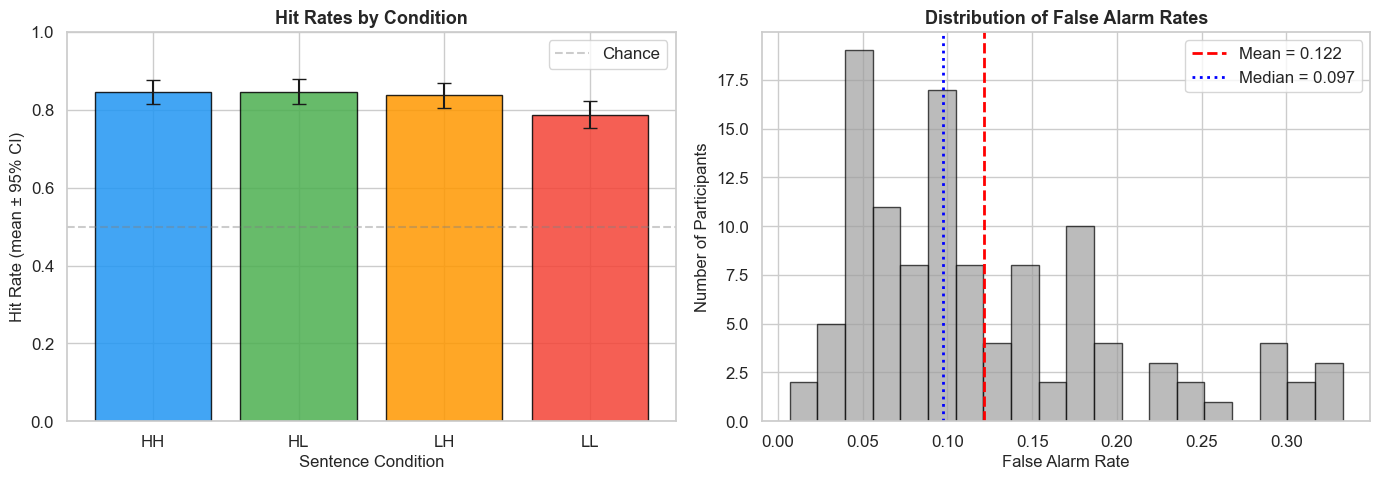

In [9]:
palette = {'HH': '#2196F3', 'HL': '#4CAF50', 'LH': '#FF9800', 'LL': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hit rates by condition
ax = axes[0]
hit_means = corrected_df.groupby('condition')['hit_rate'].agg(['mean', 'sem']).loc[cond_order]
bars = ax.bar(cond_order, hit_means['mean'], yerr=hit_means['sem']*1.96, capsize=5,
              color=[palette[c] for c in cond_order], edgecolor='black', alpha=0.85)
ax.set_xlabel('Sentence Condition', fontsize=12)
ax.set_ylabel('Hit Rate (mean ± 95% CI)', fontsize=12)
ax.set_title('Hit Rates by Condition', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Chance')
ax.legend()

# FA rate distribution
ax = axes[1]
ax.hist(fa_df['fa_rate'], bins=20, color='#9E9E9E', edgecolor='black', alpha=0.7)
ax.axvline(fa_df['fa_rate'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean = {fa_df['fa_rate'].mean():.3f}")
ax.axvline(fa_df['fa_rate'].median(), color='blue', linestyle=':', linewidth=2,
           label=f"Median = {fa_df['fa_rate'].median():.3f}")
ax.set_xlabel('False Alarm Rate', fontsize=12)
ax.set_ylabel('Number of Participants', fontsize=12)
ax.set_title('Distribution of False Alarm Rates', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Visualize Corrected Memorability Scores Across Conditions

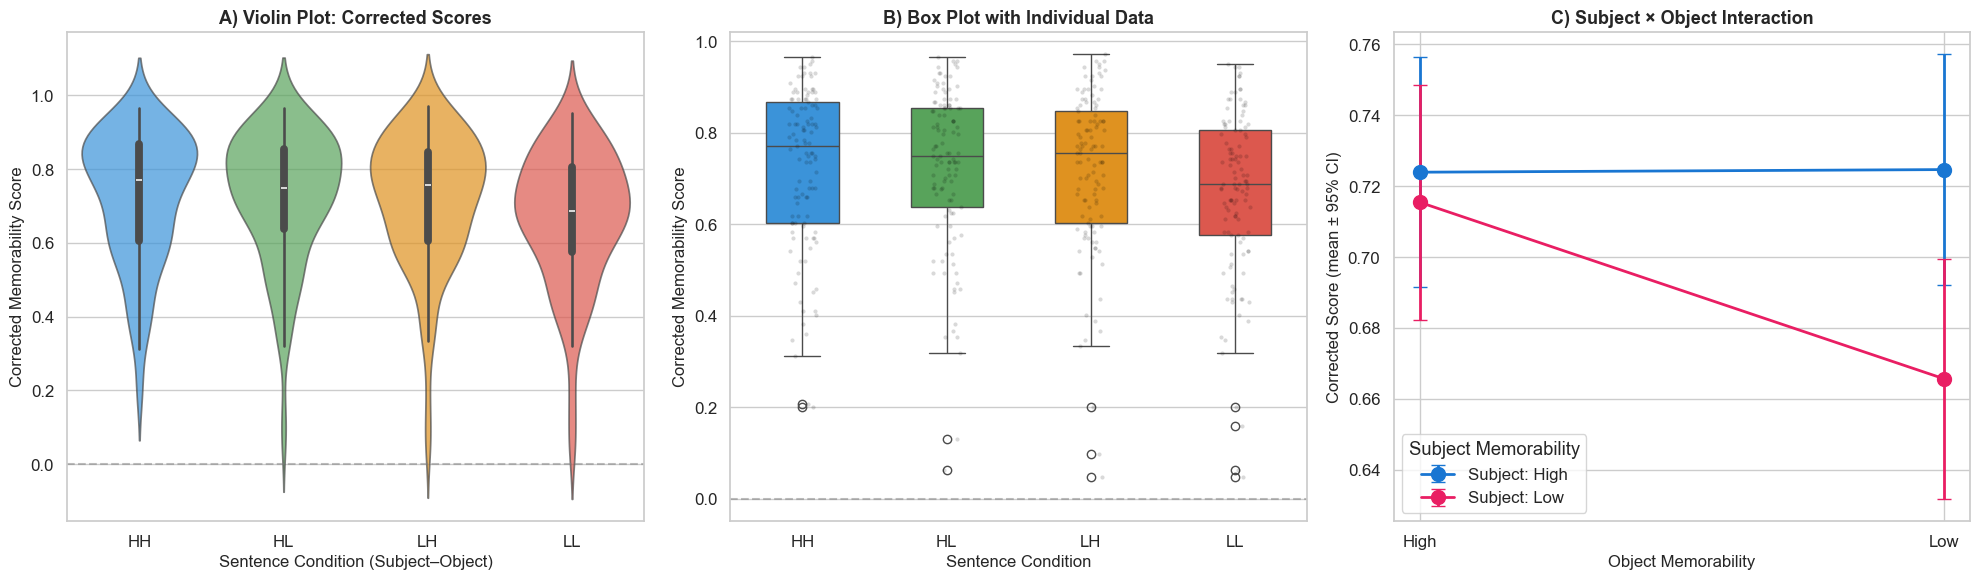

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# a) Violin + box plot
ax = axes[0]
sns.violinplot(data=corrected_df, x='condition', y='corrected_score',
               order=cond_order, palette=palette, inner='box', alpha=0.7, ax=ax)
ax.set_xlabel('Sentence Condition (Subject–Object)', fontsize=12)
ax.set_ylabel('Corrected Memorability Score', fontsize=12)
ax.set_title('A) Violin Plot: Corrected Scores', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# b) Box plot with individual points
ax = axes[1]
sns.boxplot(data=corrected_df, x='condition', y='corrected_score',
            order=cond_order, palette=palette, width=0.5, ax=ax)
sns.stripplot(data=corrected_df, x='condition', y='corrected_score',
              order=cond_order, color='black', alpha=0.15, size=3, jitter=True, ax=ax)
ax.set_xlabel('Sentence Condition', fontsize=12)
ax.set_ylabel('Corrected Memorability Score', fontsize=12)
ax.set_title('B) Box Plot with Individual Data', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# c) Interaction plot: Subject × Object memorability
ax = axes[2]
interaction_data = corrected_df.groupby(['subject_memorability', 'object_memorability'])[
    'corrected_score'].agg(['mean', 'sem']).reset_index()
for subj in ['High', 'Low']:
    sub = interaction_data[interaction_data['subject_memorability'] == subj]
    color = '#1976D2' if subj == 'High' else '#E91E63'
    ax.errorbar(sub['object_memorability'], sub['mean'], yerr=sub['sem']*1.96,
                marker='o', markersize=10, linewidth=2, capsize=5, label=f'Subject: {subj}',
                color=color)
ax.set_xlabel('Object Memorability', fontsize=12)
ax.set_ylabel('Corrected Score (mean ± 95% CI)', fontsize=12)
ax.set_title('C) Subject × Object Interaction', fontsize=13, fontweight='bold')
ax.legend(title='Subject Memorability')

plt.tight_layout()
plt.show()

## 10. Normality Testing (Shapiro-Wilk)

Before running inferential tests, we check whether corrected memorability scores follow a normal distribution. This determines whether to use parametric (ANOVA) or non-parametric (Kruskal-Wallis) tests.

Shapiro-Wilk Normality Tests:


,Condition,W statistic,p-value,Normal?
0,HH,0.923956,0.000007,No
1,HL,0.914147,0.000002,No
2,LH,0.918656,0.000004,No
3,LL,0.940491,0.000077,No


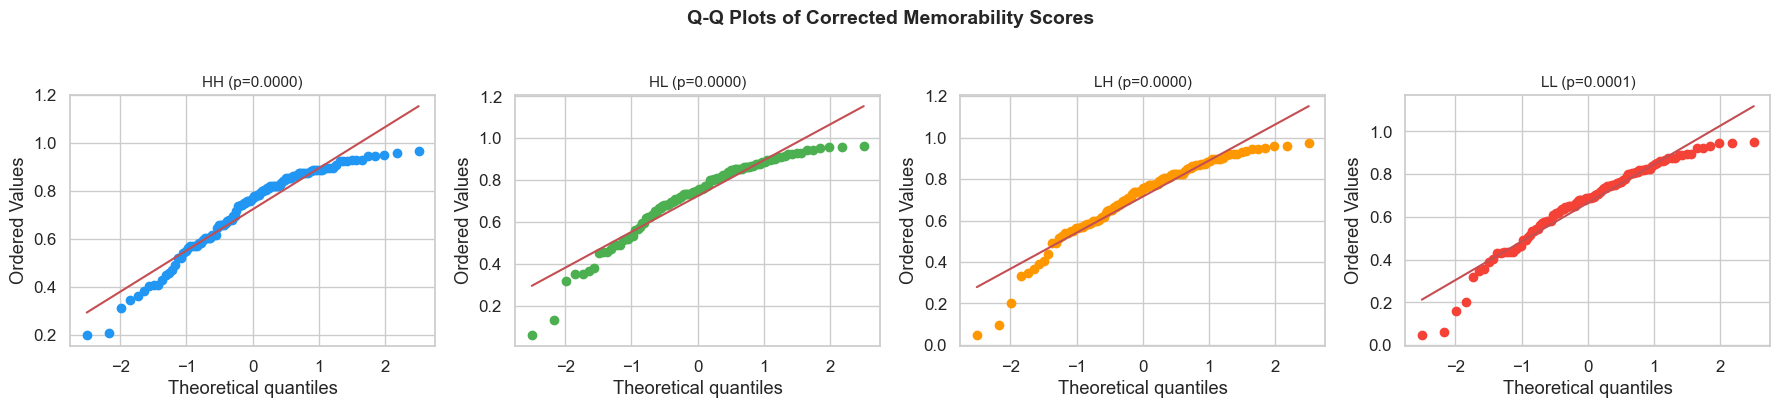


✓ All conditions show significant departures from normality (p < .05).
  → Non-parametric Kruskal-Wallis test is appropriate.


In [11]:
normality_results = []
for cond in cond_order:
    data = corrected_df[corrected_df['condition'] == cond]['corrected_score'].values
    w_stat, p_val = stats.shapiro(data)
    normality_results.append({
        'Condition': cond, 'W statistic': w_stat, 'p-value': p_val,
        'Normal?': 'Yes' if p_val >= 0.05 else 'No'
    })

df_norm = pd.DataFrame(normality_results)
print("Shapiro-Wilk Normality Tests:")
display(df_norm)

# Q-Q plots
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, cond in enumerate(cond_order):
    ax = axes[i]
    data = corrected_df[corrected_df['condition'] == cond]['corrected_score'].values
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'{cond} (p={normality_results[i]["p-value"]:.4f})', fontsize=11)
    ax.get_lines()[0].set_color(palette[cond])
plt.suptitle('Q-Q Plots of Corrected Memorability Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ All conditions show significant departures from normality (p < .05).")
print("  → Non-parametric Kruskal-Wallis test is appropriate.")

## 11. Kruskal-Wallis Test: Effect of Sentence Type (HH, HL, LH, LL)

The primary analysis: does corrected memorability differ across the four noun-memorability conditions?

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

Effect size: $\eta^2_H = \frac{H - k + 1}{N - k}$

In [12]:
groups = [corrected_df[corrected_df['condition'] == c]['corrected_score'].values for c in cond_order]
kw_stat, kw_p = stats.kruskal(*groups)

n_total = sum(len(g) for g in groups)
k = len(groups)
eta_sq = (kw_stat - k + 1) / (n_total - k)

print("=" * 60)
print("KRUSKAL-WALLIS TEST: Sentence Type Effect")
print("=" * 60)
print(f"  H({k-1}) = {kw_stat:.4f}")
print(f"  p = {kw_p:.6f}")
print(f"  Effect size η²_H = {eta_sq:.4f}")
print(f"  N = {n_total}")
print()
if kw_p < 0.05:
    print("  ★ SIGNIFICANT at α = 0.05")
    print("  → Corrected memorability scores differ across conditions.")
    print("  → Proceeding to post-hoc pairwise comparisons.")
else:
    print("  Not significant at α = 0.05")

KRUSKAL-WALLIS TEST: Sentence Type Effect
  H(3) = 10.0014
  p = 0.018554
  Effect size η²_H = 0.0156
  N = 452

  ★ SIGNIFICANT at α = 0.05
  → Corrected memorability scores differ across conditions.
  → Proceeding to post-hoc pairwise comparisons.


## 13. Post-Hoc Pairwise Comparisons: Dunn's Test with Bonferroni & Holm Corrections

Since the Kruskal-Wallis test was significant, we perform pairwise comparisons using **Dunn's test**. Two correction methods are applied:

1. **Bonferroni correction**: divides α by the number of comparisons ($\alpha_{adj} = 0.05 / 6 = 0.0083$). Very conservative — controls family-wise error rate (FWER).
2. **Holm's step-down correction**: a less conservative sequential method that also controls FWER but has more power.

With 4 conditions, there are $\binom{4}{2} = 6$ pairwise comparisons.

Dunn's Post-Hoc Test — Unadjusted p-values:


,HH,HL,LH,LL
HH,1.000000,0.984762,0.646505,0.006801
HL,0.984762,1.000000,0.660281,0.007203
LH,0.646505,0.660281,1.000000,0.024590
LL,0.006801,0.007203,0.024590,1.000000


Dunn's Post-Hoc Test — Bonferroni-adjusted p-values:


,HH,HL,LH,LL
HH,1.000000,1.000000,1.000000,0.040809
HL,1.000000,1.000000,1.000000,0.043217
LH,1.000000,1.000000,1.000000,0.147538
LL,0.040809,0.043217,0.147538,1.000000



Dunn's Post-Hoc Test — Holm-adjusted p-values:


,HH,HL,LH,LL
HH,1.000000,1.000000,1.000000,0.040809
HL,1.000000,1.000000,1.000000,0.040809
LH,1.000000,1.000000,1.000000,0.098358
LL,0.040809,0.040809,0.098358,1.000000


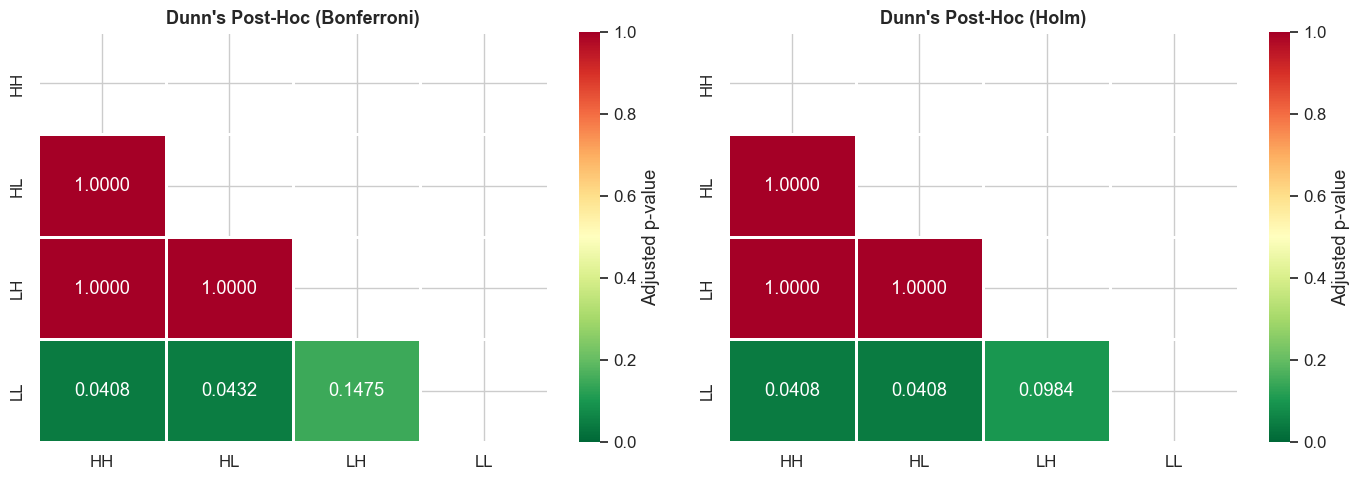


Significant pairwise comparisons (Bonferroni, p < .05):
  HH vs LL: p = 0.040809 *
  HL vs LL: p = 0.043217 *


In [13]:
# print normal p values without any correction
dunn_normal = sp.posthoc_dunn(corrected_df, val_col='corrected_score',
                              group_col='condition', p_adjust=None)
dunn_normal = dunn_normal.loc[cond_order, cond_order]

print("Dunn's Post-Hoc Test — Unadjusted p-values:")
display(dunn_normal.round(6))

# Dunn's test with Bonferroni correction
dunn_bonf = sp.posthoc_dunn(corrected_df, val_col='corrected_score',
                             group_col='condition', p_adjust='bonferroni')
dunn_bonf = dunn_bonf.loc[cond_order, cond_order]


print("Dunn's Post-Hoc Test — Bonferroni-adjusted p-values:")
display(dunn_bonf.round(6))

# Dunn's test with Holm correction
dunn_holm = sp.posthoc_dunn(corrected_df, val_col='corrected_score',
                             group_col='condition', p_adjust='holm')
dunn_holm = dunn_holm.loc[cond_order, cond_order]

print("\nDunn's Post-Hoc Test — Holm-adjusted p-values:")
display(dunn_holm.round(6))

# Heatmap visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in [(axes[0], dunn_bonf, 'Bonferroni'), (axes[1], dunn_holm, 'Holm')]:
    mask = np.triu(np.ones_like(data, dtype=bool))
    sns.heatmap(data, annot=True, fmt='.4f', cmap='RdYlGn_r',
                mask=mask, vmin=0, vmax=1, ax=ax, linewidths=1,
                cbar_kws={'label': 'Adjusted p-value'})
    ax.set_title(f"Dunn's Post-Hoc ({title})", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary of significant pairs
print("\nSignificant pairwise comparisons (Bonferroni, p < .05):")
for i in range(len(cond_order)):
    for j in range(i+1, len(cond_order)):
        p = dunn_bonf.iloc[i, j]
        if p < 0.05:
            print(f"  {cond_order[i]} vs {cond_order[j]}: p = {p:.6f} *")

---

### H1 Results: Effect of Noun Memorability Condition on Corrected Score

#### Normality

Shapiro-Wilk tests on the per-participant corrected scores in each condition revealed non-normal distributions in all four groups (all p < .001; see Q-Q plots). One-way ANOVA was therefore ruled out, and the **Kruskal-Wallis H test** was used as the non-parametric alternative.

#### Descriptive Statistics

| Condition | N | Mean | Median | SD |
|-----------|---|------|--------|----|
| HH | 113 | 0.724 | 0.771 | 0.176 |
| HL | 113 | 0.725 | 0.750 | 0.177 |
| LH | 113 | 0.716 | 0.757 | 0.179 |
| LL | 113 | 0.666 | 0.688 | 0.184 |

The LL condition had visibly lower corrected scores than the three mixed/high conditions; HH, HL, and LH were nearly identical.

#### Omnibus Test

A Kruskal-Wallis test was significant: **H(3) = 10.00, p = .019, η²_H = 0.016** (small effect). This indicates that corrected memorability scores differed across at least one pair of conditions.

#### Post-Hoc Pairwise Tests (Dunn's, Holm-corrected)

| Pair | p_Holm | Significant? |
|------|--------|--------------|
| HH vs HL | 1.000 | No |
| HH vs LH | 1.000 | No |
| HH vs LL | **0.041** | Yes ★ |
| HL vs LH | 1.000 | No |
| HL vs LL | **0.041** | Yes ★ |
| LH vs LL | 0.098 | No (marginal) |

#### Interpretation

The LL condition (both subject and object nouns low-memorability) produced significantly lower corrected scores than HH (p = .041) and HL (p = .041). The difference between LH and LL approached but did not reach significance after Holm correction (p = .098). No significant differences were found among HH, HL, and LH.

**Conclusion**: The hypothesis is partially supported. Sentences with both nouns low in memorability were significantly harder to recognise, but a single high-memorability noun (HH or HL) was sufficient to yield equivalent performance — no additional benefit was seen from having *both* nouns high (HH vs HL: p = 1.00). The effect size is small (η²_H = 0.016), suggesting noun memorability explains a modest proportion of variance in corrected scores.


## 13. Wilcoxon Signed-Rank Test: Effect of Voice (Active vs Passive)

Testing whether the voice at the test presentation (Active vs Passive) affects corrected memorability. Each participant contributes **both** an Active and a Passive corrected score — observations are therefore **paired by participant**, not independent. The appropriate test is the **Wilcoxon Signed-Rank test** (the paired, non-parametric equivalent of a paired t-test), not Mann-Whitney U which assumes independence.


Voice Corrected Scores:


,mean,std,count
voice_label,,,
Active,0.7016,0.1605,113
Passive,0.7132,0.1653,113



NORMALITY CHECK — Signed Differences (Active − Passive)
(Wilcoxon Signed-Rank is used if differences are non-normal)
  N pairs           = 113
  Shapiro-Wilk:  W  = 0.9636,  p = 0.003592
  ★ Differences are NON-NORMAL  → Wilcoxon Signed-Rank test is appropriate.


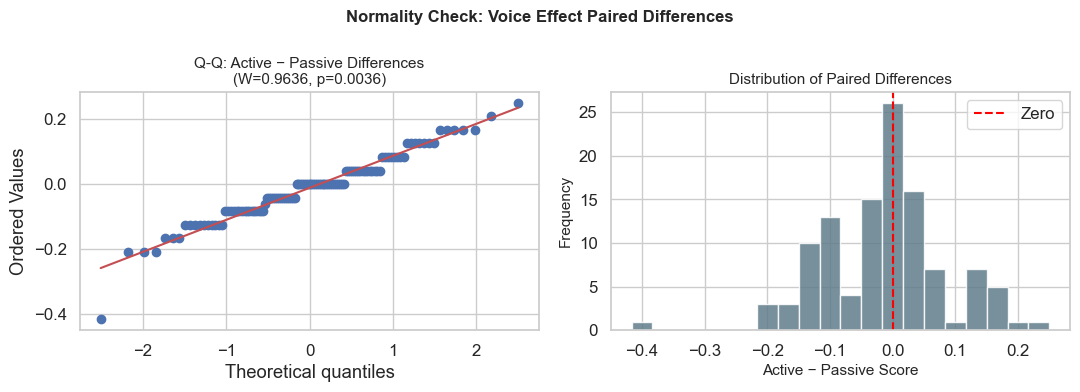


Wilcoxon Signed-Rank Test: Active vs Passive Voice (paired by participant)
  W = 1612.00, p = 0.200033
  N pairs = 113  (non-zero differences = 87)
  Matched rank-biserial r = 0.1578
  ✗ NOT significant at α = 0.05
  → Voice at test does not significantly affect corrected memorability.


In [14]:

# Compute voice-level corrected scores
ir_hits_voice = df_valid[(df_valid['Event'] == 'IR pressed') & 
                          df_valid['is_repeat'] & ~df_valid['is_validation']].copy()
targets_voice = targets_shown.groupby(['pid', 'voice']).size().reset_index(name='n_shown')
voice_hit = ir_hits_voice.groupby(['pid', 'voice'])['Accuracy IR'].sum().reset_index(name='hits')

voice_df = targets_voice.merge(voice_hit, on=['pid', 'voice'], how='left')
voice_df['hits'] = voice_df['hits'].fillna(0)
voice_df['hit_rate'] = voice_df['hits'] / voice_df['n_shown']
voice_df = voice_df.merge(fa_df[['pid', 'fa_rate']], on='pid', how='left')
voice_df['corrected_score'] = voice_df['hit_rate'] - voice_df['fa_rate']
voice_df['voice_label'] = voice_df['voice'].map({'A': 'Active', 'P': 'Passive'})

# Descriptive
print("Voice Corrected Scores:")
voice_desc = voice_df.groupby('voice_label')['corrected_score'].agg(['mean', 'std', 'count'])
display(voice_desc.round(4))

# Pivot to align each participant's Active and Passive scores side-by-side
voice_wide = voice_df.pivot(index='pid', columns='voice', values='corrected_score').dropna()
active_paired  = voice_wide['A'].values   # Active score for each participant
passive_paired = voice_wide['P'].values   # Passive score for same participant

# ── NORMALITY CHECK — Signed Differences (Active − Passive) ───────────────────
# For the paired Wilcoxon Signed-Rank test the relevant quantity is the
# distribution of within-participant differences. A paired t-test would
# require these differences to be normal; Wilcoxon does not.
print("\n" + "=" * 65)
print("NORMALITY CHECK — Signed Differences (Active − Passive)")
print("(Wilcoxon Signed-Rank is used if differences are non-normal)")
print("=" * 65)

diffs = active_paired - passive_paired
sw_stat_d, sw_p_d = stats.shapiro(diffs)
print(f"  N pairs           = {len(diffs)}")
print(f"  Shapiro-Wilk:  W  = {sw_stat_d:.4f},  p = {sw_p_d:.6f}")
if sw_p_d < 0.05:
    print("  ★ Differences are NON-NORMAL  → Wilcoxon Signed-Rank test is appropriate.")
else:
    print("  ✓ Differences appear NORMAL   → Paired t-test would also be valid.")

fig_n, ax_n = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(diffs, dist='norm', plot=ax_n[0])
ax_n[0].set_title(f'Q-Q: Active − Passive Differences\n(W={sw_stat_d:.4f}, p={sw_p_d:.4f})',
                  fontsize=11)
ax_n[1].hist(diffs, bins=20, color='#607D8B', edgecolor='white', alpha=0.85)
ax_n[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
ax_n[1].set_xlabel('Active − Passive Score', fontsize=11)
ax_n[1].set_ylabel('Frequency', fontsize=11)
ax_n[1].set_title('Distribution of Paired Differences', fontsize=11)
ax_n[1].legend()
plt.suptitle('Normality Check: Voice Effect Paired Differences',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Wilcoxon Signed-Rank Test ─────────────────────────────────────────────────
n_pairs = len(active_paired)
w_stat, w_p = stats.wilcoxon(active_paired, passive_paired, alternative='two-sided')

# Effect size: matched rank-biserial r = (R+ - R-) / (R+ + R-)
n_nz = int(np.sum(diffs != 0))   # non-zero differences
r_rb = 1 - (4 * w_stat) / (n_nz * (n_nz + 1))

print(f"\nWilcoxon Signed-Rank Test: Active vs Passive Voice (paired by participant)")
print(f"  W = {w_stat:.2f}, p = {w_p:.6f}")
print(f"  N pairs = {n_pairs}  (non-zero differences = {n_nz})")
print(f"  Matched rank-biserial r = {r_rb:.4f}")
if w_p < 0.05:
    print("  ★ SIGNIFICANT at α = 0.05")
else:
    print("  ✗ NOT significant at α = 0.05")
    print("  → Voice at test does not significantly affect corrected memorability.")


## 14. Interaction Analysis: Word Memorability × Voice

Testing whether the full 8-group design (4 conditions × 2 voices) shows significant differences, and visualizing the Condition × Voice interaction.

NORMALITY CHECK — 8 Condition × Voice Groups (Shapiro-Wilk)
(Kruskal-Wallis is used if any group is non-normal)


,N,W,p,Normal?
Group,,,,
HH_Active,113,0.9227,0.000006,No
HH_Passive,113,0.8932,0.000000,No
HL_Active,113,0.8934,0.000000,No
HL_Passive,113,0.9081,0.000001,No
LH_Active,113,0.9330,0.000026,No
LH_Passive,113,0.8913,0.000000,No
LL_Active,113,0.9182,0.000003,No
LL_Passive,113,0.9528,0.000549,No



8/8 groups depart from normality.
★ Non-normality detected → Kruskal-Wallis test is appropriate.


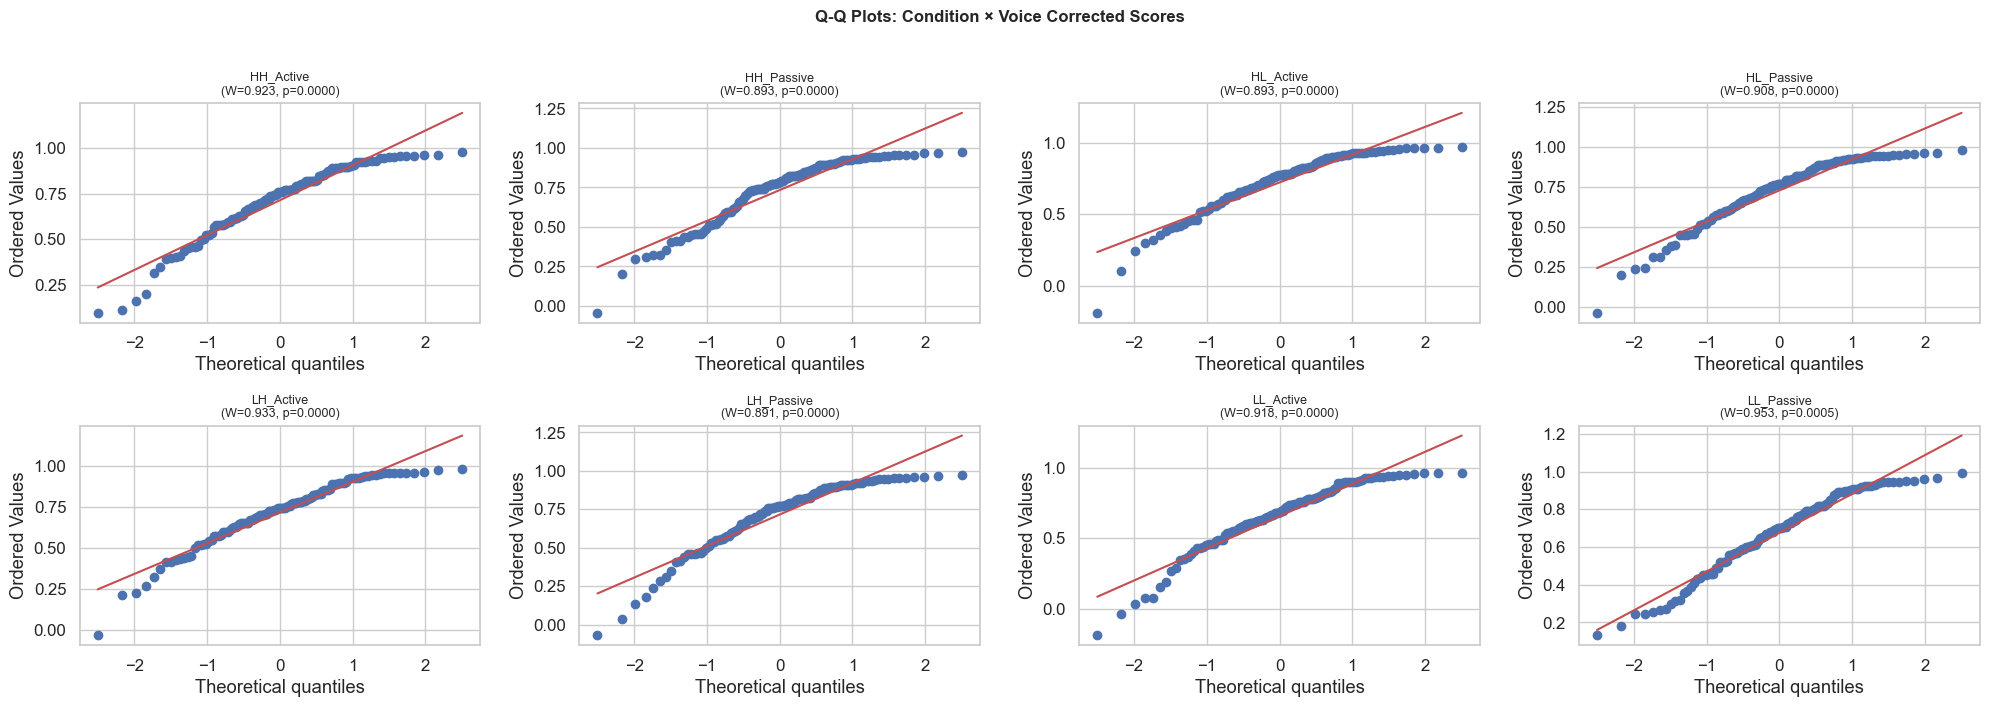


Kruskal-Wallis Test: 8-group (Condition × Voice)
  H(7) = 14.0333, p = 0.050592
  ✗ NOT significant — no evidence for Condition × Voice interaction

Condition × Voice Corrected Scores:


mean     std
condition voice_label                
HH        Active       0.7144  0.1963
          Passive      0.7335  0.2033
HL        Active       0.7210  0.2028
          Passive      0.7284  0.2003
LH        Active       0.7151  0.1914
          Passive      0.7158  0.2140
LL        Active       0.6561  0.2344
          Passive      0.6753  0.2072

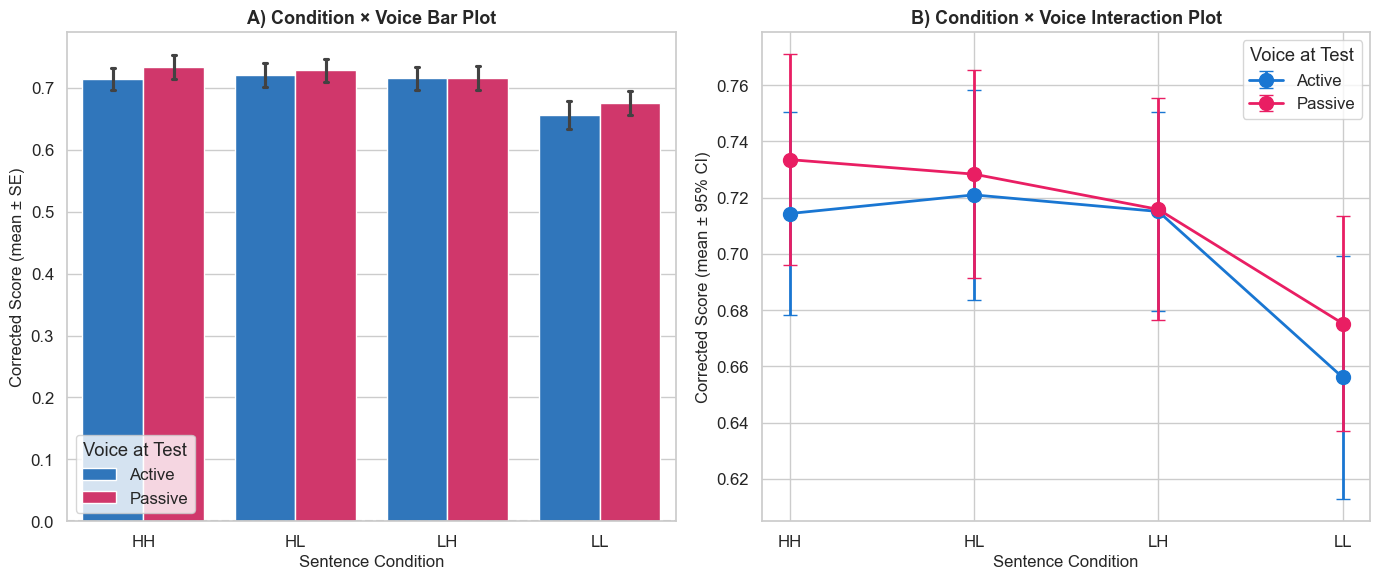

In [15]:

# Compute condition × voice scores
ir_cv = df_valid[(df_valid['Event'] == 'IR pressed') & 
                  df_valid['is_repeat'] & ~df_valid['is_validation']].copy()
tgt_cv = targets_shown.groupby(['pid', 'condition', 'voice']).size().reset_index(name='n_shown')
hit_cv = ir_cv.groupby(['pid', 'condition', 'voice'])['Accuracy IR'].sum().reset_index(name='hits')

cv_df = tgt_cv.merge(hit_cv, on=['pid', 'condition', 'voice'], how='left')
cv_df['hits'] = cv_df['hits'].fillna(0)
cv_df['hit_rate'] = cv_df['hits'] / cv_df['n_shown']
cv_df = cv_df.merge(fa_df[['pid', 'fa_rate']], on='pid', how='left')
cv_df['corrected_score'] = cv_df['hit_rate'] - cv_df['fa_rate']
cv_df['voice_label'] = cv_df['voice'].map({'A': 'Active', 'P': 'Passive'})
cv_df['group'] = cv_df['condition'] + '_' + cv_df['voice_label']

group_names = sorted(cv_df['group'].unique())
groups_8 = [cv_df[cv_df['group'] == g]['corrected_score'].values for g in group_names]

# ── NORMALITY CHECK — 8 Condition × Voice groups ─────────────────────────────
# Each group's corrected scores must be normal for a one-way ANOVA.
# Kruskal-Wallis is used because normality fails in at least one group.
print("=" * 68)
print("NORMALITY CHECK — 8 Condition × Voice Groups (Shapiro-Wilk)")
print("(Kruskal-Wallis is used if any group is non-normal)")
print("=" * 68)
norm_cv = []
for g, grp in zip(group_names, groups_8):
    sw_s, sw_p = stats.shapiro(grp)
    norm_cv.append({'Group': g, 'N': len(grp),
                    'W': round(sw_s, 4), 'p': round(sw_p, 6),
                    'Normal?': 'Yes' if sw_p >= 0.05 else 'No'})
norm_cv_df = pd.DataFrame(norm_cv).set_index('Group')
display(norm_cv_df)

n_nonnorm = (norm_cv_df['Normal?'] == 'No').sum()
print(f"\n{n_nonnorm}/{len(group_names)} groups depart from normality.")
if n_nonnorm > 0:
    print("★ Non-normality detected → Kruskal-Wallis test is appropriate.")
else:
    print("✓ All groups appear normal → ANOVA would also be valid.")

# Q-Q plots for all 8 groups
fig_cv, axes_cv = plt.subplots(2, 4, figsize=(20, 7))
for ax_cv, g, grp in zip(axes_cv.flatten(), group_names, groups_8):
    stats.probplot(grp, dist='norm', plot=ax_cv)
    sw_s, sw_p = stats.shapiro(grp)
    ax_cv.set_title(f'{g}\n(W={sw_s:.3f}, p={sw_p:.4f})', fontsize=9)
plt.suptitle('Q-Q Plots: Condition × Voice Corrected Scores',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Kruskal-Wallis on 8 groups ────────────────────────────────────────────────
kw8_stat, kw8_p = stats.kruskal(*groups_8)

print("\nKruskal-Wallis Test: 8-group (Condition × Voice)")
print(f"  H({len(group_names)-1}) = {kw8_stat:.4f}, p = {kw8_p:.6f}")
if kw8_p < 0.05:
    print("  ★ SIGNIFICANT")
else:
    print("  ✗ NOT significant — no evidence for Condition × Voice interaction")

# Descriptive table
print("\nCondition × Voice Corrected Scores:")
cv_summary = cv_df.groupby(['condition', 'voice_label'])['corrected_score'].agg(
    ['mean', 'std']).round(4)
display(cv_summary)

# Visualization
voice_palette = {'Active': '#1976D2', 'Passive': '#E91E63'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# a) Grouped bar plot
ax = axes[0]
sns.barplot(data=cv_df, x='condition', y='corrected_score', hue='voice_label',
            order=cond_order, hue_order=['Active', 'Passive'],
            palette=voice_palette, ax=ax, errorbar='se', capsize=0.05)
ax.set_xlabel('Sentence Condition', fontsize=12)
ax.set_ylabel('Corrected Score (mean ± SE)', fontsize=12)
ax.set_title('A) Condition × Voice Bar Plot', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(title='Voice at Test')

# b) Interaction line plot
ax = axes[1]
for voice, color in voice_palette.items():
    sub = cv_df[cv_df['voice_label'] == voice].groupby('condition')['corrected_score'].agg(
        ['mean', 'sem']).loc[cond_order]
    ax.errorbar(range(len(cond_order)), sub['mean'], yerr=sub['sem']*1.96,
                marker='o', markersize=10, linewidth=2, capsize=5, label=voice, color=color)
ax.set_xticks(range(len(cond_order)))
ax.set_xticklabels(cond_order)
ax.set_xlabel('Sentence Condition', fontsize=12)
ax.set_ylabel('Corrected Score (mean ± 95% CI)', fontsize=12)
ax.set_title('B) Condition × Voice Interaction Plot', fontsize=13, fontweight='bold')
ax.legend(title='Voice at Test')

plt.tight_layout()
plt.show()


---

### H2 Results: Effect of Voice (Active vs Passive) on Corrected Score

#### Normality of Paired Differences

The within-participant differences (Active − Passive corrected score) were computed for each of the 113 participants. A Shapiro-Wilk test on these differences indicated a departure from normality (W = 0.964, p = .004), ruling out a paired t-test and directing the analysis to the **Wilcoxon Signed-Rank test**.

#### Descriptive Statistics

| Voice | N | Mean | SD |
|-------|---|------|----|
| Active | 113 | 0.702 | 0.161 |
| Passive | 113 | 0.713 | 0.165 |

Passive sentences had a numerically higher mean corrected score, though the difference was small (Δ ≈ 0.011).

#### Paired Test (Wilcoxon Signed-Rank)

The Wilcoxon Signed-Rank test on paired Active vs Passive scores was **not significant**: W = 1612.0, p = .200, matched rank-biserial r = 0.158 (small effect).

There is no evidence that the voice at which a sentence was presented at test significantly affected corrected memorability scores.

#### Exploratory: Condition × Voice (8-Group Kruskal-Wallis)

As an extension, an 8-group Kruskal-Wallis test across all Condition × Voice combinations was run. The result was borderline non-significant: **H(7) = 14.03, p = .051**. The descriptive pattern by cell is shown below:

| Condition | Active Mean | Passive Mean |
|-----------|-------------|--------------|
| HH | 0.714 | 0.734 |
| HL | 0.721 | 0.728 |
| LH | 0.715 | 0.716 |
| LL | 0.656 | 0.675 |

The Passive > Active trend appears consistent across conditions but is small and did not reach significance in the omnibus test (p = .051). No formal post-hoc was run given the non-significant omnibus result.

#### Interpretation

**Conclusion**: H2 is not supported. Neither the overall voice effect (p = .200) nor the Condition × Voice omnibus test (p = .051) reached the α = .05 threshold. Sentence voice at test presentation does not appear to meaningfully modulate corrected recognition scores. The marginal p = .051 in the 8-group test warrants cautious attention but cannot be interpreted as evidence of an interaction without a significant omnibus result.


## 20. Accuracy Trend Across Blocks (Fatigue / Time Effect)

**Hypothesis**: Recognition accuracy (hit rate on repeat presentations) *decreases* as the experiment progresses from Block 1 → Block 2 → Block 3, consistent with fatigue or reduced engagement.

**Analysis plan**:
1. Compute per-participant hit rate (correct IR hits / repeat targets shown) separately for each block.
2. **Friedman test** — omnibus non-parametric repeated-measures test for any block effect.
3. **Spearman correlation** (block number vs hit rate, pooled) — tests for a monotonic trend; one-sided p checks the *decreasing* direction.
4. **Pairwise Wilcoxon Signed-Rank tests** (Holm-corrected) — identifies which consecutive blocks differ.


NORMALITY CHECK — Per-Participant Hit Rate per Block (Shapiro-Wilk)
(Friedman test is used if any block's distribution is non-normal)


,N,W,p,Normal?
Block,,,,
Block 1,107,0.8534,0.0,No
Block 2,107,0.8044,0.0,No
Block 3,107,0.8618,0.0,No



3/3 blocks depart from normality.
★ Non-normality detected → Friedman test is appropriate.


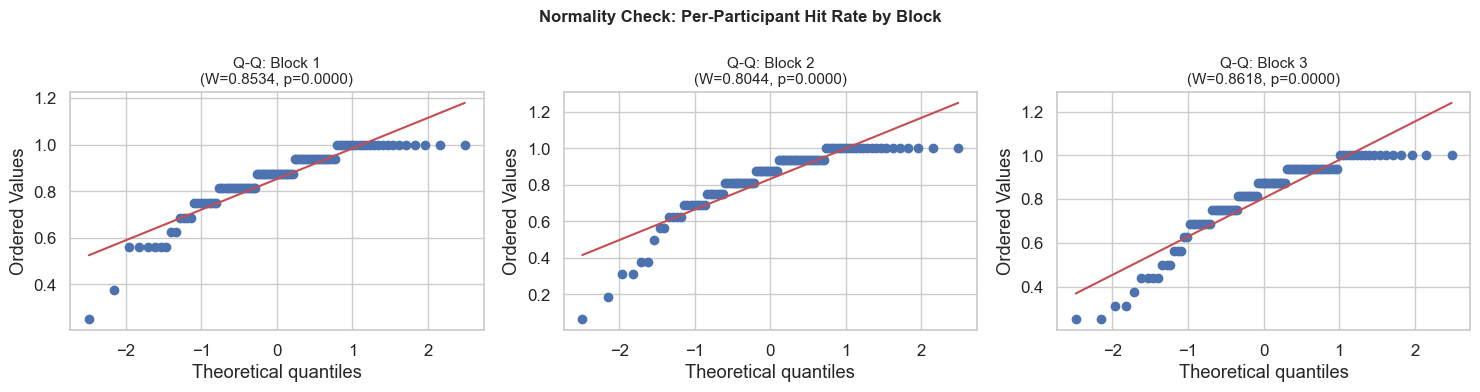


BLOCK-LEVEL HIT RATE
Null H0: no block effect | Alt H1: accuracy decreases over blocks
  Block 1: M=0.8528  Mdn=0.8750  SD=0.1406  N=107
  Block 2: M=0.8329  Mdn=0.8750  SD=0.1847  N=107
  Block 3: M=0.8043  Mdn=0.8750  SD=0.1857  N=107

1. Friedman Test (omnibus block effect):
   chi2(2) = 7.8145,  p = 0.020096
   ★ SIGNIFICANT omnibus block effect detected.

2. Spearman Correlation (block number vs hit rate):
   rho = -0.0908,  p (two-sided) = 0.104297
   p (one-sided, H1: rho < 0) = 0.052148
   NOT significant: no monotonic accuracy trend across blocks.

3. Pairwise Wilcoxon Signed-Rank Tests (Holm-corrected):
   Block 1 vs Block 3: W=1213.5  p_raw=0.0042  p_Holm=0.0125  r=0.351  ★
   Block 2 vs Block 3: W=1421.5  p_raw=0.0497  p_Holm=0.0994  r=0.240  ✗
   Block 1 vs Block 2: W=1181.0  p_raw=0.2607  p_Holm=0.2607  r=0.149  ✗


In [16]:

# ── Per-participant hit rate per block ─────────────────────────────────────────
tgt_by_block = df_valid[
    (df_valid['Event'] == 'Sentence shown') &
    df_valid['is_repeat'] &
    ~df_valid['is_validation']
].groupby(['pid', 'block']).size().reset_index(name='n_shown')

hits_by_block = df_valid[
    (df_valid['Event'] == 'IR pressed') &
    df_valid['is_repeat'] &
    ~df_valid['is_validation'] &
    (df_valid['Accuracy IR'] == 1)
].groupby(['pid', 'block']).size().reset_index(name='n_hits')

blk_acc = tgt_by_block.merge(hits_by_block, on=['pid', 'block'], how='left')
blk_acc['n_hits']   = blk_acc['n_hits'].fillna(0)
blk_acc['hit_rate'] = blk_acc['n_hits'] / blk_acc['n_shown']

blk_wide    = blk_acc.pivot(index='pid', columns='block', values='hit_rate').dropna()
block_labels = sorted(blk_wide.columns.tolist())   # e.g. [0, 1, 2]

# ── NORMALITY CHECK — Per-participant hit rate in each block ──────────────────
# Friedman test is the non-parametric repeated-measures alternative to
# a one-way repeated-measures ANOVA, which would require normality per block.
print("=" * 65)
print("NORMALITY CHECK — Per-Participant Hit Rate per Block (Shapiro-Wilk)")
print("(Friedman test is used if any block's distribution is non-normal)")
print("=" * 65)
norm_blk = []
for b in block_labels:
    col = blk_wide[b].values
    sw_s, sw_p = stats.shapiro(col)
    norm_blk.append({'Block': f'Block {b+1}', 'N': len(col),
                     'W': round(sw_s, 4), 'p': round(sw_p, 6),
                     'Normal?': 'Yes' if sw_p >= 0.05 else 'No'})
norm_blk_df = pd.DataFrame(norm_blk).set_index('Block')
display(norm_blk_df)

n_nonnorm_blk = (norm_blk_df['Normal?'] == 'No').sum()
print(f"\n{n_nonnorm_blk}/{len(block_labels)} blocks depart from normality.")
if n_nonnorm_blk > 0:
    print("★ Non-normality detected → Friedman test is appropriate.")
else:
    print("✓ All blocks appear normal → RM-ANOVA would also be valid.")

# Q-Q plots per block
fig_blk, axes_blk = plt.subplots(1, len(block_labels), figsize=(5 * len(block_labels), 4))
if len(block_labels) == 1:
    axes_blk = [axes_blk]
for ax_b, b in zip(axes_blk, block_labels):
    sw_s, sw_p = stats.shapiro(blk_wide[b].values)
    stats.probplot(blk_wide[b].values, dist='norm', plot=ax_b)
    ax_b.set_title(f'Q-Q: Block {b+1}\n(W={sw_s:.4f}, p={sw_p:.4f})', fontsize=11)
plt.suptitle('Normality Check: Per-Participant Hit Rate by Block',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Descriptive statistics ─────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("BLOCK-LEVEL HIT RATE")
print("Null H0: no block effect | Alt H1: accuracy decreases over blocks")
print("=" * 65)
for b in block_labels:
    col = blk_wide[b]
    print(f"  Block {b+1}: M={col.mean():.4f}  Mdn={col.median():.4f}  "
          f"SD={col.std():.4f}  N={len(col)}")

# ── 1. Friedman Test (omnibus) ────────────────────────────────────────────────
fried2_stat, fried2_p = stats.friedmanchisquare(*[blk_wide[b] for b in block_labels])
print(f"\n1. Friedman Test (omnibus block effect):")
print(f"   chi2({len(block_labels)-1}) = {fried2_stat:.4f},  p = {fried2_p:.6f}")
if fried2_p < 0.05:
    print("   ★ SIGNIFICANT omnibus block effect detected.")
else:
    print("   NOT significant: no significant omnibus block effect.")

# ── 2. Spearman correlation (monotonic trend) ─────────────────────────────────
blk_long_h2 = blk_wide.reset_index().melt(id_vars='pid', var_name='block', value_name='hit_rate')
rho2, rho2_p = stats.spearmanr(blk_long_h2['block'], blk_long_h2['hit_rate'])
# One-sided p for H1: accuracy decreases (rho < 0)
p_one_sided = rho2_p / 2 if rho2 < 0 else 1.0 - rho2_p / 2

print(f"\n2. Spearman Correlation (block number vs hit rate):")
print(f"   rho = {rho2:.4f},  p (two-sided) = {rho2_p:.6f}")
print(f"   p (one-sided, H1: rho < 0) = {p_one_sided:.6f}")
if p_one_sided < 0.05 and rho2 < 0:
    print("   ★ SIGNIFICANT negative trend: accuracy decreases across blocks.")
elif p_one_sided < 0.05 and rho2 > 0:
    print("   ★ Accuracy increases across blocks (opposite of H1).")
else:
    print("   NOT significant: no monotonic accuracy trend across blocks.")

# ── 3. Pairwise Wilcoxon Signed-Rank tests (Holm-corrected) ──────────────────
pairs = [(block_labels[i], block_labels[j])
         for i in range(len(block_labels)) for j in range(i+1, len(block_labels))]
raw_results = []
for b1, b2 in pairs:
    wsr_pw, p_pw = stats.wilcoxon(blk_wide[b1], blk_wide[b2], alternative='two-sided')
    n_nz_pw = int(np.sum(blk_wide[b1].values - blk_wide[b2].values != 0))
    r_pw = 1 - (4 * wsr_pw) / (n_nz_pw * (n_nz_pw + 1)) if n_nz_pw > 0 else 0
    raw_results.append({'b1': b1, 'b2': b2, 'W': wsr_pw, 'p_raw': p_pw, 'r': r_pw})

raw_results.sort(key=lambda x: x['p_raw'])
running_max, holm_ps = 0, []
for rank, res in enumerate(raw_results):
    p_adj = max(min(1.0, res['p_raw'] * (len(raw_results) - rank)), running_max)
    running_max = p_adj
    holm_ps.append(p_adj)

print(f"\n3. Pairwise Wilcoxon Signed-Rank Tests (Holm-corrected):")
for res, p_holm in zip(raw_results, holm_ps):
    sig = "★" if p_holm < 0.05 else "✗"
    print(f"   Block {res['b1']+1} vs Block {res['b2']+1}: "
          f"W={res['W']:.1f}  p_raw={res['p_raw']:.4f}  p_Holm={p_holm:.4f}  "
          f"r={res['r']:.3f}  {sig}")


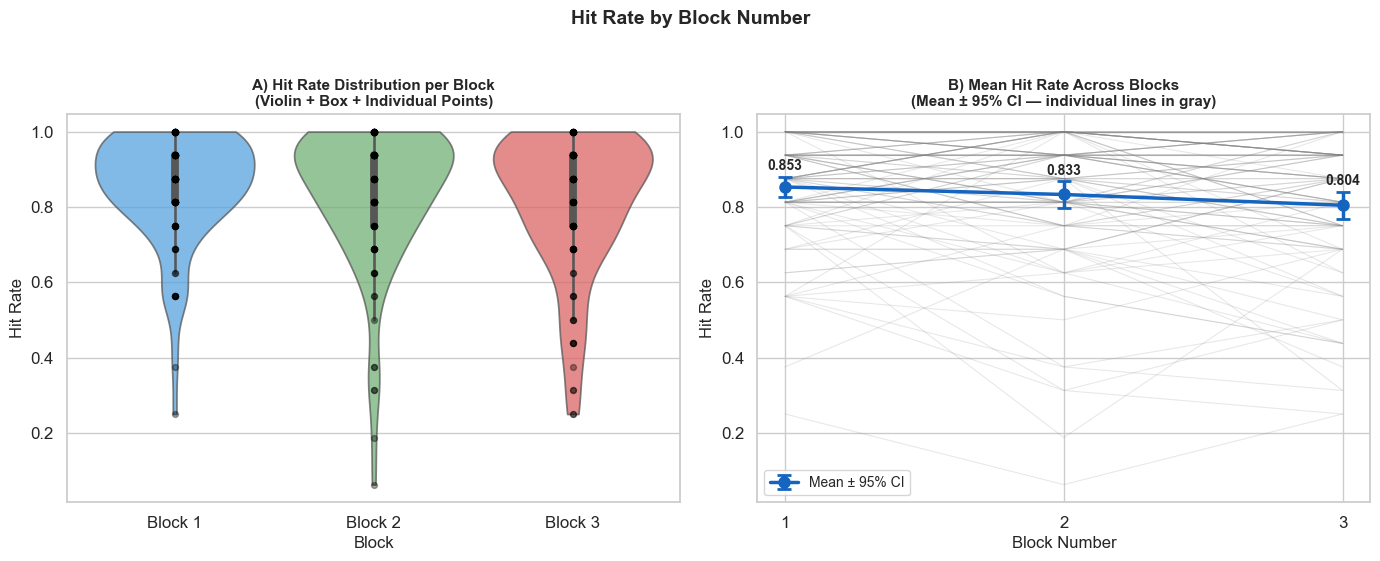

In [17]:

# ── Hit Rate vs Block Number: Visualization ────────────────────────────────────
blk_acc['block_label'] = blk_acc['block'].apply(lambda b: f'Block {b+1}')
block_display  = [f'Block {b+1}' for b in block_labels]
palette_blk    = dict(zip(block_display, ['#42A5F5', '#66BB6A', '#EF5350'][:len(block_labels)]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── A) Violin + box plot: per-participant hit-rate distribution per block ──────
ax = axes[0]
sns.violinplot(data=blk_acc, x='block_label', y='hit_rate',
               order=block_display, palette=palette_blk,
               inner='box', cut=0, alpha=0.75, ax=ax)
for i, b in enumerate(block_labels):
    ax.scatter([i] * len(blk_wide[b]), blk_wide[b].values,
               color='black', alpha=0.35, s=18, zorder=3)
ax.set_xlabel('Block', fontsize=12)
ax.set_ylabel('Hit Rate', fontsize=12)
ax.set_title('A) Hit Rate Distribution per Block\n(Violin + Box + Individual Points)',
             fontsize=11, fontweight='bold')

# ── B) Mean ± 95% CI line plot with individual spaghetti lines ─────────────────
ax = axes[1]
x_pos = [b + 1 for b in block_labels]
# Spaghetti lines (individual participants)
for _, row in blk_wide.iterrows():
    ax.plot(x_pos, [row[b] for b in block_labels],
            color='gray', alpha=0.18, linewidth=0.8)
# Group mean ± 95% CI
means = [blk_wide[b].mean() for b in block_labels]
cis   = [1.96 * blk_wide[b].sem()  for b in block_labels]
ax.errorbar(x_pos, means, yerr=cis,
            fmt='o-', color='#1565C0', linewidth=2.5, markersize=8,
            capsize=5, capthick=2, label='Mean ± 95% CI', zorder=5)
for x, m, ci in zip(x_pos, means, cis):
    ax.text(x, m + ci + 0.01, f'{m:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xlabel('Block Number', fontsize=12)
ax.set_ylabel('Hit Rate', fontsize=12)
ax.set_title('B) Mean Hit Rate Across Blocks\n(Mean ± 95% CI — individual lines in gray)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('Hit Rate by Block Number', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


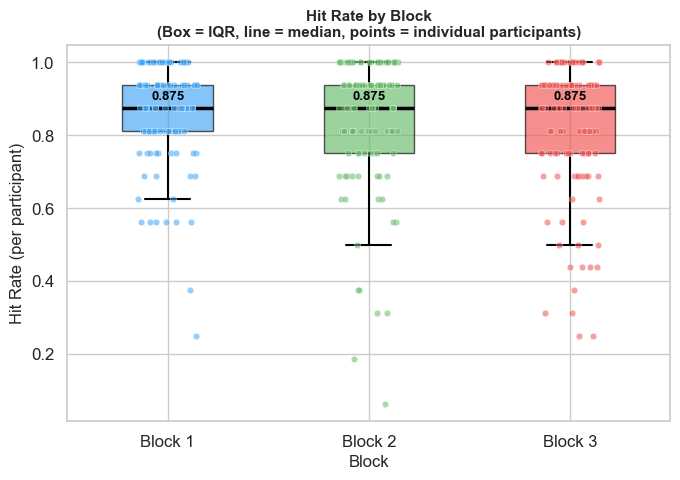

In [18]:

# ── Hit Rate vs Block Number: Box Plot with Jittered Points ───────────────────
fig, ax = plt.subplots(figsize=(7, 5))

# Boxplot
bp = ax.boxplot(
    [blk_wide[b].values for b in block_labels],
    positions=range(len(block_labels)),
    widths=0.45,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.4),
    showfliers=False,           # individual points shown separately
)

blk_color_list = ['#42A5F5', '#66BB6A', '#EF5350'][:len(block_labels)]
for patch, color in zip(bp['boxes'], blk_color_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

# Jittered individual points
np.random.seed(42)
for i, b in enumerate(block_labels):
    vals = blk_wide[b].values
    jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(i + jitter, vals, color=blk_color_list[i],
               alpha=0.55, s=22, zorder=3, edgecolors='white', linewidths=0.4)

# Annotate median values
for i, b in enumerate(block_labels):
    mdn = blk_wide[b].median()
    ax.text(i, mdn + 0.015, f'{mdn:.3f}',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='black')

ax.set_xticks(range(len(block_labels)))
ax.set_xticklabels(block_display, fontsize=12)
ax.set_xlabel('Block', fontsize=12)
ax.set_ylabel('Hit Rate (per participant)', fontsize=12)
ax.set_title('Hit Rate by Block\n(Box = IQR, line = median, points = individual participants)',
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 20b. Post-Hoc Analyses: Block Accuracy Trend

Given that the Friedman test was significant and Block 1 vs Block 3 differed, three further analyses strengthen the conclusion:

1. **Page's L Trend Test** — the purpose-built test for *monotonically ordered* alternatives in repeated measures. More powerful than Friedman for directional hypotheses (H1: Block 1 ≥ Block 2 ≥ Block 3). Gives a single, focused p-value for the ordered-decrease hypothesis.

2. **Condition × Block Interaction** — tests whether the magnitude of the accuracy drop differs across the four sentence conditions (HH, HL, LH, LL). If LL sentences fatigue participants more, the block decline would be steeper for that condition.

3. **Individual Trajectory Classification** — classifies each participant as *Monotone Decline* (B1 > B2 > B3), *Monotone Increase*, or *Non-Monotone*. Reveals how pervasive the fatigue effect is at the person level.


1. PAGE'S L TREND TEST  (H1: Block 1 ≥ Block 2 ≥ Block 3)
   L = 1318.0,  p = 0.010058
   ★ SIGNIFICANT: accuracy follows the predicted monotone decrease.
   → H1 (fatigue / time effect) is supported by the ordered trend test.

2. CONDITION × BLOCK INTERACTION
   (Friedman test per condition — does block effect depend on condition?)

  Mean hit rate per condition × block:

           Block 1  Block 2  Block 3
condition                           
HH          0.8829   0.8463   0.8147
HL          0.8829   0.8486   0.8147
LH          0.8333   0.8417   0.8371
LL          0.8041   0.7936   0.7701

  Friedman test per condition:
  HH: chi2(2)=6.676  p=0.0355  ★   [0.888 → 0.846 → 0.813]
  HL: chi2(2)=5.421  p=0.0665  ✗   [0.886 → 0.848 → 0.808]
  LH: chi2(2)=0.519  p=0.7716  ✗   [0.829 → 0.843 → 0.836]
  LL: chi2(2)=4.396  p=0.1111  ✗   [0.808 → 0.794 → 0.759]

3. INDIVIDUAL TRAJECTORY CLASSIFICATION
   (Block 1 → Block 2 → Block 3 per participant)

  Trajectory counts (N = 107):
    Non-Mono

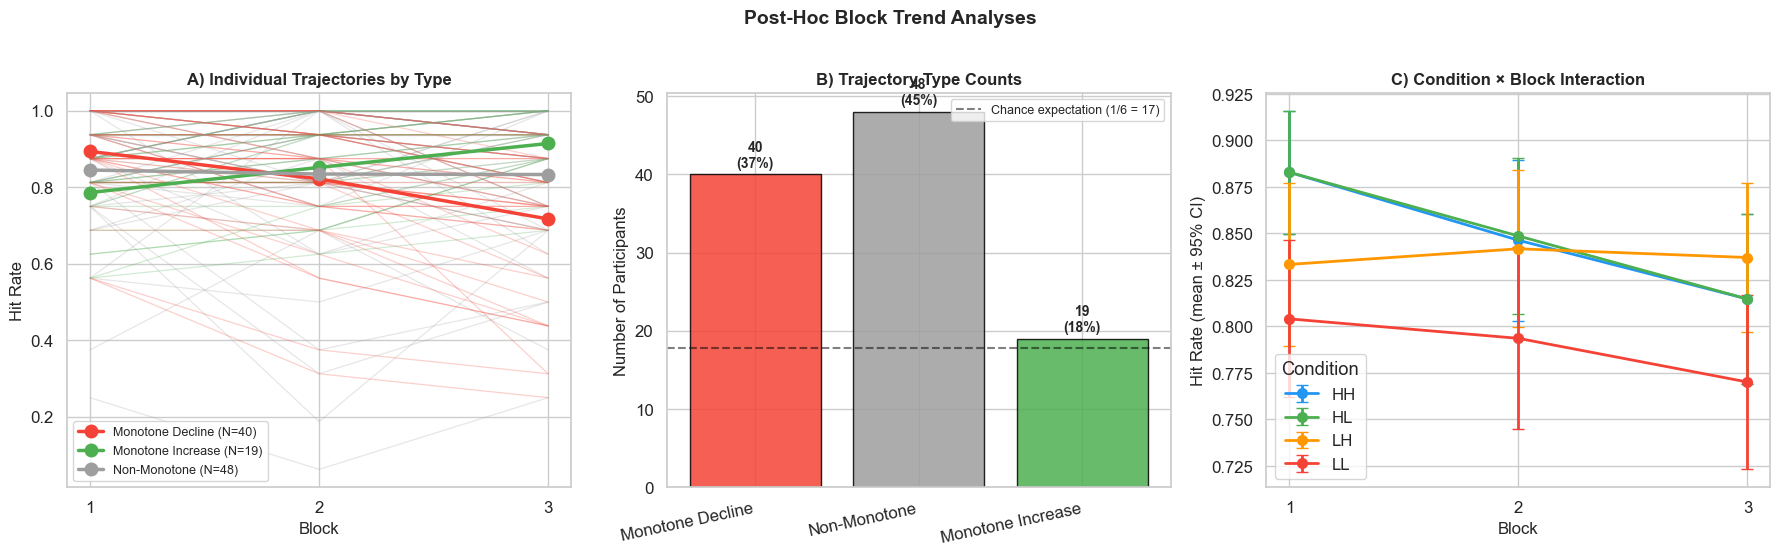

In [19]:

from scipy.stats import page_trend_test

# blk_wide columns are [0, 1, 2] = Block 1, 2, 3 (already built in Section 20)
data_matrix = blk_wide[block_labels].values   # shape: (n_participants, 3)

# ══════════════════════════════════════════════════════════════════════════════
# 1. Page's L Trend Test (monotone decrease: Block1 ≥ Block2 ≥ Block3)
# predicted_ranks=[3,2,1]: col-0 (Block 1) is highest, col-2 (Block 3) is lowest
# ══════════════════════════════════════════════════════════════════════════════
page_result = page_trend_test(data_matrix, predicted_ranks=[3, 2, 1])
print("=" * 65)
print("1. PAGE'S L TREND TEST  (H1: Block 1 ≥ Block 2 ≥ Block 3)")
print("=" * 65)
print(f"   L = {page_result.statistic:.1f},  p = {page_result.pvalue:.6f}")
if page_result.pvalue < 0.05:
    print("   ★ SIGNIFICANT: accuracy follows the predicted monotone decrease.")
    print("   → H1 (fatigue / time effect) is supported by the ordered trend test.")
else:
    print("   NOT significant: trend is not reliably monotone across blocks.")

# ══════════════════════════════════════════════════════════════════════════════
# 2. Condition × Block Interaction
#    Within each condition, run a Friedman test on per-participant block hit rates
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("2. CONDITION × BLOCK INTERACTION")
print("   (Friedman test per condition — does block effect depend on condition?)")
print("=" * 65)

# Build per-participant × condition × block corrected scores
tgt_cond_blk = df_valid[
    (df_valid['Event'] == 'Sentence shown') &
    df_valid['is_repeat'] &
    ~df_valid['is_validation']
].groupby(['pid', 'condition', 'block']).size().reset_index(name='n_shown')

hits_cond_blk = df_valid[
    (df_valid['Event'] == 'IR pressed') &
    df_valid['is_repeat'] &
    ~df_valid['is_validation'] &
    (df_valid['Accuracy IR'] == 1)
].groupby(['pid', 'condition', 'block']).size().reset_index(name='n_hits')

cb_df = tgt_cond_blk.merge(hits_cond_blk, on=['pid', 'condition', 'block'], how='left')
cb_df['n_hits']   = cb_df['n_hits'].fillna(0)
cb_df['hit_rate'] = cb_df['n_hits'] / cb_df['n_shown']
cb_df = cb_df.dropna(subset=['condition'])

# Condition means per block (for table)
print(f"\n  Mean hit rate per condition × block:\n")
cb_means = cb_df.groupby(['condition', 'block'])['hit_rate'].mean().unstack('block')
cb_means.columns = [f'Block {int(c)+1}' for c in cb_means.columns]
print(cb_means.round(4).to_string())

# Friedman per condition
print(f"\n  Friedman test per condition:")
for cond in cond_order:
    sub = cb_df[cb_df['condition'] == cond]
    wide = sub.pivot(index='pid', columns='block', values='hit_rate').dropna()
    if wide.shape[1] < 3 or len(wide) < 6:
        print(f"  {cond}: insufficient data (N={len(wide)}), skipping.")
        continue
    cols = sorted(wide.columns.tolist())
    fr_s, fr_p = stats.friedmanchisquare(*[wide[c] for c in cols])
    sig = "★" if fr_p < 0.05 else "✗"
    b_means = [wide[c].mean() for c in cols]
    trend = " → ".join([f"{m:.3f}" for m in b_means])
    print(f"  {cond}: chi2(2)={fr_s:.3f}  p={fr_p:.4f}  {sig}   [{trend}]")

# ══════════════════════════════════════════════════════════════════════════════
# 3. Individual Trajectory Classification
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("3. INDIVIDUAL TRAJECTORY CLASSIFICATION")
print("   (Block 1 → Block 2 → Block 3 per participant)")
print("=" * 65)

def classify_trajectory(row):
    b1, b2, b3 = row[block_labels[0]], row[block_labels[1]], row[block_labels[2]]
    if b1 >= b2 >= b3 and b1 > b3:
        return 'Monotone Decline'
    elif b1 <= b2 <= b3 and b1 < b3:
        return 'Monotone Increase'
    else:
        return 'Non-Monotone'

blk_wide['trajectory'] = blk_wide.apply(classify_trajectory, axis=1)
traj_counts = blk_wide['trajectory'].value_counts()

print(f"\n  Trajectory counts (N = {len(blk_wide)}):")
for label, count in traj_counts.items():
    pct = 100 * count / len(blk_wide)
    print(f"    {label:<20}: {count:>3}  ({pct:.1f}%)")

# Chi-square goodness-of-fit: is decline more common than expected by chance?
# Under H0 (no trend): each of 6 orderings equally likely → P(monotone decline) = 1/6
n_total_traj = len(blk_wide)
n_decline = traj_counts.get('Monotone Decline', 0)
expected_decline = n_total_traj / 6
chi2_traj = (n_decline - expected_decline)**2 / expected_decline
p_traj = 1 - stats.chi2.cdf(chi2_traj, df=1)   # one-tailed: more declines than chance
print(f"\n  Chi-square test: observed declines vs. chance expectation (1/6 = {100/6:.1f}%)")
print(f"    Observed: {n_decline}/{n_total_traj} = {100*n_decline/n_total_traj:.1f}%")
print(f"    Expected under H0: {expected_decline:.1f}")
print(f"    chi2(1) = {chi2_traj:.3f},  p (one-tailed) = {p_traj:.4f}")
if p_traj < 0.05:
    print("    ★ Monotone decline is more frequent than expected by chance.")
else:
    print("    ✗ Monotone decline rate is not above chance expectation.")

# ── Visualization ─────────────────────────────────────────────────────────────
traj_colors = {'Monotone Decline': '#F44336',
               'Monotone Increase': '#4CAF50',
               'Non-Monotone':      '#9E9E9E'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
x_pos = np.array(block_labels) + 1

# A) Spaghetti plot coloured by trajectory
ax = axes[0]
for pid_val, row in blk_wide.iterrows():
    col = traj_colors[row['trajectory']]
    ax.plot(x_pos, [row[b] for b in block_labels],
            color=col, alpha=0.25, linewidth=0.9)
# Group means per trajectory
for traj, col in traj_colors.items():
    sub = blk_wide[blk_wide['trajectory'] == traj]
    if len(sub) == 0:
        continue
    means = [sub[b].mean() for b in block_labels]
    ax.plot(x_pos, means, 'o-', color=col, linewidth=2.5,
            markersize=9, label=f"{traj} (N={len(sub)})", zorder=5)
ax.set_xlabel('Block', fontsize=12)
ax.set_ylabel('Hit Rate', fontsize=12)
ax.set_title('A) Individual Trajectories by Type', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.legend(fontsize=9)

# B) Trajectory proportion bar chart
ax = axes[1]
traj_order = ['Monotone Decline', 'Non-Monotone', 'Monotone Increase']
counts_ordered = [traj_counts.get(t, 0) for t in traj_order]
colors_ordered = [traj_colors[t] for t in traj_order]
bars = ax.bar(traj_order, counts_ordered, color=colors_ordered,
              edgecolor='black', alpha=0.85)
for bar, c in zip(bars, counts_ordered):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{c}\n({100*c/n_total_traj:.0f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(n_total_traj / 6, color='black', linestyle='--', alpha=0.5,
           label=f'Chance expectation (1/6 = {n_total_traj//6})')
ax.set_ylabel('Number of Participants', fontsize=12)
ax.set_title('B) Trajectory Type Counts', fontsize=12, fontweight='bold')
ax.set_xticklabels(traj_order, rotation=12, ha='right')
ax.legend(fontsize=9)

# C) Condition × Block line plot
ax = axes[2]
cond_palette_loc = {'HH': '#2196F3', 'HL': '#4CAF50', 'LH': '#FF9800', 'LL': '#F44336'}
for cond in cond_order:
    sub = cb_df[cb_df['condition'] == cond]
    means = sub.groupby('block')['hit_rate'].mean()
    sems  = sub.groupby('block')['hit_rate'].sem()
    ax.errorbar(means.index + 1, means.values, yerr=sems.values * 1.96,
                marker='o', linewidth=2, markersize=7, capsize=4,
                label=cond, color=cond_palette_loc[cond])
ax.set_xlabel('Block', fontsize=12)
ax.set_ylabel('Hit Rate (mean ± 95% CI)', fontsize=12)
ax.set_title('C) Condition × Block Interaction', fontsize=12, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.legend(title='Condition')

plt.suptitle('Post-Hoc Block Trend Analyses', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---

### H3 Results: Block Accuracy Trend (Fatigue / Time-on-Task Effect)

#### Normality

Shapiro-Wilk tests on per-participant hit rates in each block showed strong departures from normality in all three blocks (Block 1: W = 0.853; Block 2: W = 0.804; Block 3: W = 0.862; all p < .001). This ruled out a repeated-measures ANOVA and directed the analysis to the non-parametric **Friedman test** with **Spearman correlation** for trend and **Page's L** for the ordered alternative.

#### Descriptive Statistics

| Block | N | Mean | Median | SD |
|-------|---|------|--------|----|
| Block 1 | 107 | 0.853 | 0.875 | 0.141 |
| Block 2 | 107 | 0.833 | 0.875 | 0.185 |
| Block 3 | 107 | 0.804 | 0.875 | 0.186 |

Mean hit rates declined monotonically across blocks (Δ Block 1→3 = −0.049). Medians remained constant at 0.875 across all blocks, indicating a ceiling effect in the central tendency while the lower tail of the distribution spread downward.

#### Omnibus Test (Friedman)

The Friedman test was significant: **χ²(2) = 7.81, p = .020**. There is an overall block effect — hit rates differ across the three blocks.

#### Trend Analysis (Spearman Correlation)

A Spearman correlation between block number and hit rate yielded ρ = −0.091 (two-sided p = .104; one-sided p for H: ρ < 0 = .052). The one-sided p narrowly missed the α = .05 threshold, indicating a trend toward monotonic decline that did not reach conventional significance. The Spearman test has lower power than Page's L for ordered-ranks designs (see below).

#### Pairwise Post-Hoc Tests (Wilcoxon, Holm-corrected)

| Comparison | W | p_Holm | r | Significant? |
|------------|---|--------|---|--------------|
| Block 1 vs Block 2 | 1181.0 | 0.261 | 0.149 | No |
| Block 1 vs Block 3 | 1213.5 | **0.013** | 0.351 | Yes ★ |
| Block 2 vs Block 3 | 1421.5 | 0.099 | 0.240 | No (marginal) |

Only the Block 1 vs Block 3 comparison survived Holm correction (p = .013, medium effect r = 0.351). Block 2 vs Block 3 was marginal (p = .099). The intermediate drop (Block 1→Block 2) was not significant, suggesting that accuracy loss accumulates gradually and becomes detectable primarily at the end of the experiment.

#### Page's L Trend Test

Page's L directly tests the ordered alternative H: Block 1 ≥ Block 2 ≥ Block 3: **L = 1318.0, p = .010**. This is significant, providing stronger evidence for a monotone decline than the Spearman correlation, because it fully exploits the predicted rank ordering.

#### Individual Trajectory Analysis

| Trajectory | N | % |
|------------|---|---|
| Non-Monotone | 48 | 44.9% |
| Monotone Decline | 40 | 37.4% |
| Monotone Increase | 19 | 17.8% |

A chi-square test showed that the proportion of participants showing monotone decline (37.4%) significantly exceeded chance expectation (1/6 ≈ 16.7%): χ²(1) = 27.55, p < .001.

#### Condition × Block Interaction

Separate Friedman tests within each condition showed:

| Condition | χ²(2) | p | Significant? | Trend |
|-----------|--------|---|--------------|-------|
| HH | 6.68 | .036 | Yes ★ | 0.883 → 0.846 → 0.815 |
| HL | 5.42 | .067 | No (marginal) | 0.886 → 0.848 → 0.808 |
| LH | 0.52 | .772 | No | 0.829 → 0.843 → 0.836 |
| LL | 4.40 | .111 | No | 0.808 → 0.794 → 0.770 |

The block effect was significant only for HH sentences. Notably, LH showed almost no decline across blocks, while LL started lowest and remained lowest throughout.

#### Interpretation

**Conclusion**: H3 is supported. Hit rates declined significantly from Block 1 to Block 3 (Friedman p = .020; Page's L p = .010; Block 1 vs Block 3 Wilcoxon p = .013, r = 0.351). The decline is gradual and accumulated: the Block 1 → Block 2 drop was not significant, but the cumulative drop to Block 3 was. More participants showed monotone decline (37.4%) than expected by chance (p < .001). The effect is condition-dependent: HH sentences show the clearest block decline; LH sentences show almost none.


## 21. Reaction Time Analysis: Does RT Differ Across Conditions?

**Research question**: Do correct-hit reaction times differ significantly across the four noun-memorability conditions (HH, HL, LH, LL)?

**Rationale**: Stronger memory traces may produce faster recognition, but we make **no prior assumption about the direction or ordering** of conditions. The omnibus test first asks whether any difference exists; post-hoc pairwise tests then reveal *which* pairs differ and in *which direction*, allowing the empirical ranking to emerge from the data.

**Analysis plan**:
1. **Normality check (Shapiro-Wilk + Q-Q plots)** — determines whether parametric tests are applicable.
2. **Descriptive statistics** — mean, median, SD per condition; observed ranking reported after, not assumed before.
3. **Kruskal-Wallis H test** — non-directional omnibus test: is there *any* RT difference across conditions?
4. **Dunn's post-hoc pairwise tests (Holm-corrected)** — identifies *which* pairs significantly differ and the direction of each difference.
5. **Effect size** — rank-biserial $r$ for each pair.
6. **Visualisations** — violin plots, mean ± 95% CI, empirical CDF.


NORMALITY CHECK — Reaction Time per Condition (Shapiro-Wilk)
(Kruskal-Wallis used if RT is non-normal)


,N,W,p,Normal?
Condition,,,,
HH,1126,0.9302,0.0,No
HL,1126,0.9392,0.0,No
LH,1112,0.9287,0.0,No
LL,1048,0.9359,0.0,No



4/4 conditions depart from normality.
★ Non-normality detected → Kruskal-Wallis is appropriate.


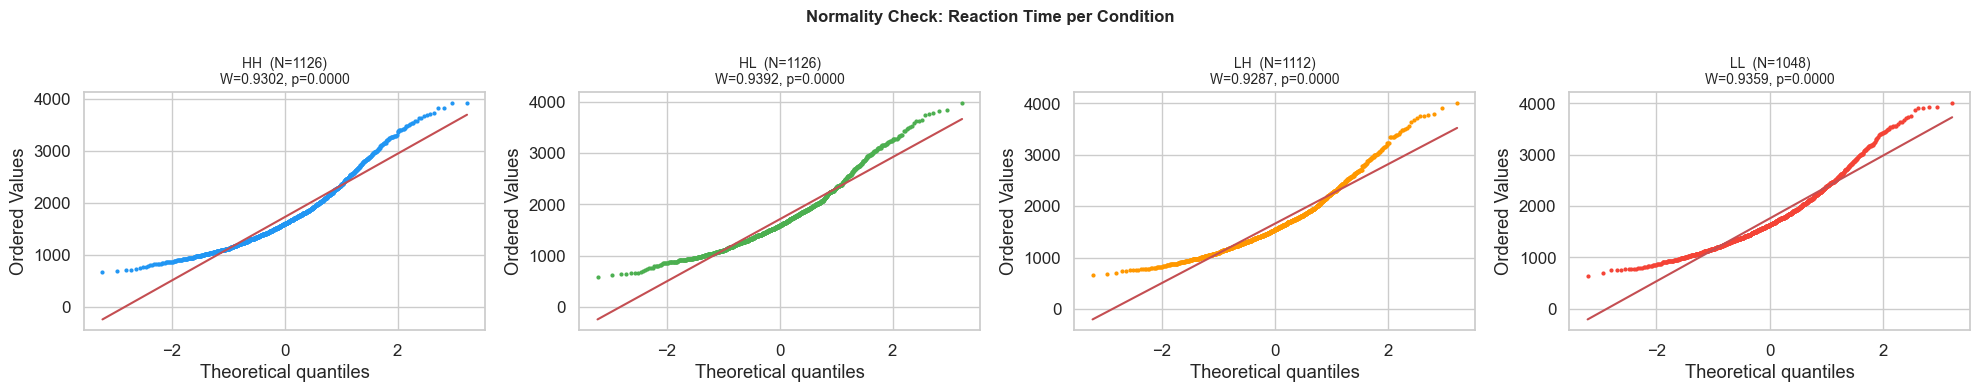


REACTION TIME (ms) FOR CORRECT IR HITS — BY CONDITION


,N,Mean,Median,SD,SE,Q1,Q3
Condition,,,,,,,
HH,1126,1725.31,1596.5,630.09,18.78,1252.00,2039.75
HL,1126,1713.25,1589.0,621.41,18.52,1260.25,2017.75
LH,1112,1660.93,1544.0,597.05,17.90,1228.00,1939.25
LL,1048,1761.00,1634.5,632.79,19.55,1308.75,2098.25



Empirical RT ranking (fastest → slowest): LH < HL < HH < LL

1. Kruskal-Wallis Test (omnibus, two-sided H0: all conditions equal):
   H(3) = 14.8808,  p = 0.001921,  eta²_H = 0.0027
   ★ SIGNIFICANT: RT differs across at least one pair of conditions.
   → Proceeding to post-hoc tests to identify which pairs differ.

2. Dunn's Post-Hoc Pairwise Tests (Holm-corrected):
   (Direction determined empirically from data)
   HH vs HL: p_Holm=0.8161  r=-0.006  direction=HH>HL  ✗
   HH vs LH: p_Holm=0.1179  r=-0.055  direction=HH>LH  ✗
   HH vs LL: p_Holm=0.2123  r=0.040  direction=HH<LL  ✗
   HL vs LH: p_Holm=0.1686  r=-0.050  direction=HL>LH  ✗
   HL vs LL: p_Holm=0.1955  r=0.046  direction=HL<LL  ✗
   LH vs LL: p_Holm=0.0008  r=0.096  direction=LH<LL  ★


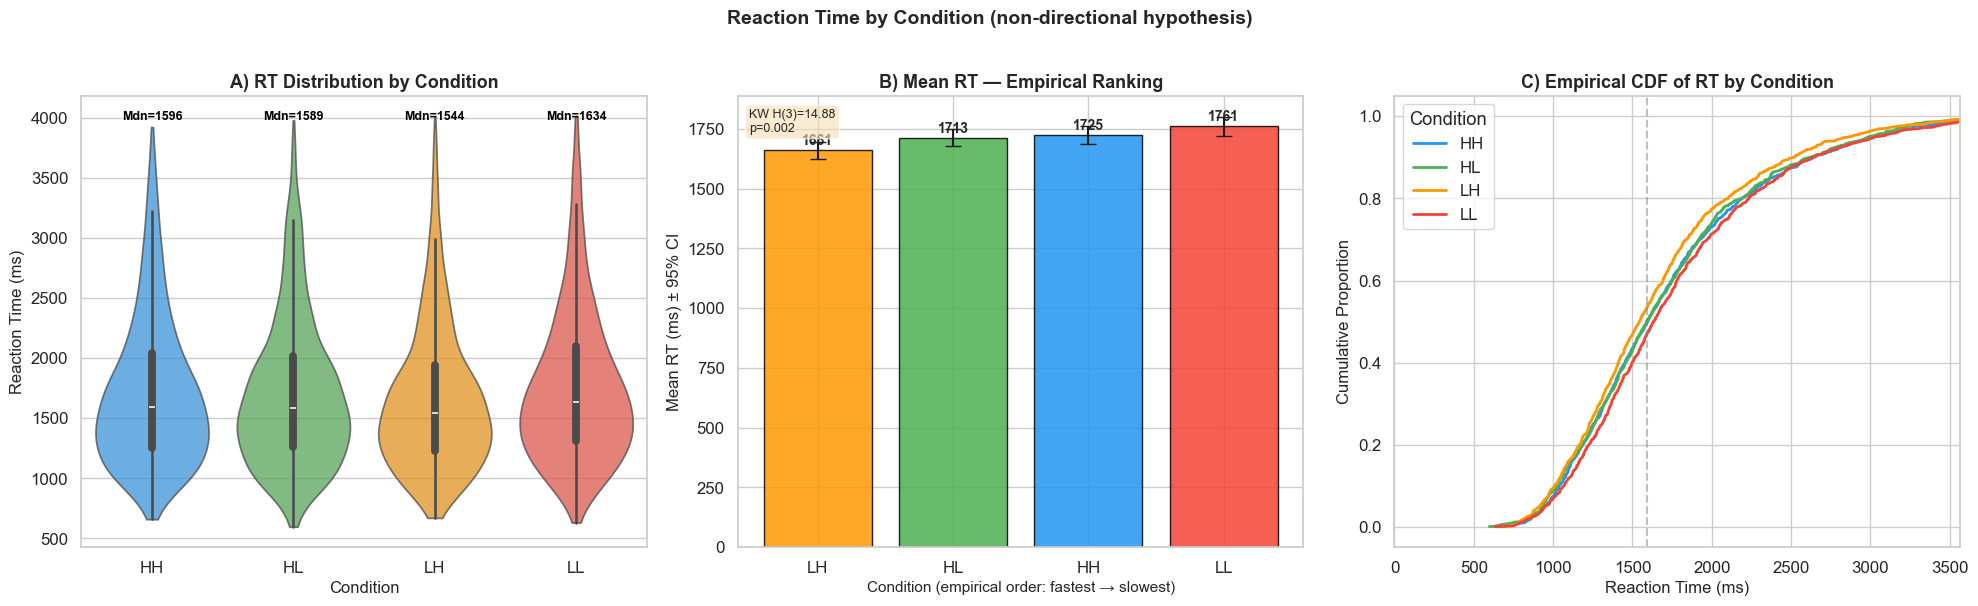


Summary: Empirical RT ranking (fastest → slowest): LH < HL < HH < LL


In [20]:

# ── Build RT dataset: correct IR hits on repeat presentations, valid blocks ────
rt_df = df_valid[
    (df_valid['Event'] == 'IR pressed') &
    df_valid['is_repeat'] &
    ~df_valid['is_validation'] &
    (df_valid['Accuracy IR'] == 1)
].copy()

rt_df['condition'] = rt_df['stim_prefix'].map(COND_MAP)
rt_df = rt_df.dropna(subset=['condition', 'Reaction_time_IR'])
rt_df = rt_df[rt_df['Reaction_time_IR'] >= 200]   # remove implausibly fast responses (<200 ms)

rt_order = ['HH', 'HL', 'LH', 'LL']
rt_groups = [rt_df[rt_df['condition'] == c]['Reaction_time_IR'].values for c in rt_order]
rt_palette = {'HH': '#2196F3', 'HL': '#4CAF50', 'LH': '#FF9800', 'LL': '#F44336'}

# ── NORMALITY CHECK — RT per condition ────────────────────────────────────────
# RT distributions are almost always right-skewed. Kruskal-Wallis does not
# assume normality; a one-way ANOVA on raw RTs would.
print("=" * 65)
print("NORMALITY CHECK — Reaction Time per Condition (Shapiro-Wilk)")
print("(Kruskal-Wallis used if RT is non-normal)")
print("=" * 65)
norm_rt = []
for cond, grp in zip(rt_order, rt_groups):
    sw_s, sw_p = stats.shapiro(grp[:5000])   # SW valid for n <= 5000
    norm_rt.append({'Condition': cond, 'N': len(grp),
                    'W': round(sw_s, 4), 'p': round(sw_p, 6),
                    'Normal?': 'Yes' if sw_p >= 0.05 else 'No'})
norm_rt_df = pd.DataFrame(norm_rt).set_index('Condition')
display(norm_rt_df)

n_nonnorm_rt = (norm_rt_df['Normal?'] == 'No').sum()
print(f"\n{n_nonnorm_rt}/{len(rt_order)} conditions depart from normality.")
if n_nonnorm_rt > 0:
    print("★ Non-normality detected → Kruskal-Wallis is appropriate.")
else:
    print("✓ All conditions appear normal → one-way ANOVA would also be valid.")

# Q-Q plots for each condition
fig_rt_n, axes_rt_n = plt.subplots(1, 4, figsize=(20, 4))
for ax_r, cond, grp in zip(axes_rt_n, rt_order, rt_groups):
    sw_s, sw_p = stats.shapiro(grp[:5000])
    stats.probplot(grp, dist='norm', plot=ax_r)
    ax_r.get_lines()[0].set(color=rt_palette[cond], markersize=2)
    ax_r.set_title(f'{cond}  (N={len(grp)})\nW={sw_s:.4f}, p={sw_p:.4f}', fontsize=10)
plt.suptitle('Normality Check: Reaction Time per Condition',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 1. Descriptive statistics ──────────────────────────────────────────────────
print("\n" + "=" * 65)
print("REACTION TIME (ms) FOR CORRECT IR HITS — BY CONDITION")
print("=" * 65)
rt_desc = []
for cond, grp in zip(rt_order, rt_groups):
    rt_desc.append({
        'Condition': cond, 'N': len(grp),
        'Mean': np.mean(grp), 'Median': np.median(grp),
        'SD': np.std(grp, ddof=1),
        'SE': np.std(grp, ddof=1) / np.sqrt(len(grp)),
        'Q1': np.percentile(grp, 25), 'Q3': np.percentile(grp, 75),
    })
rt_desc_df = pd.DataFrame(rt_desc).set_index('Condition')
display(rt_desc_df.round(2))

# Empirical ranking (ascending mean RT = fastest first)
observed_means = rt_desc_df['Mean']
empirical_rank = ' < '.join(observed_means.sort_values().index.tolist())
print(f"\nEmpirical RT ranking (fastest → slowest): {empirical_rank}")

# ── 2. Kruskal-Wallis (omnibus, non-directional) ───────────────────────────────
kw_rt2_stat, kw_rt2_p = stats.kruskal(*rt_groups)
n_rt_total = sum(len(g) for g in rt_groups)
eta_rt = (kw_rt2_stat - len(rt_groups) + 1) / (n_rt_total - len(rt_groups))

print(f"\n1. Kruskal-Wallis Test (omnibus, two-sided H0: all conditions equal):")
print(f"   H({len(rt_groups)-1}) = {kw_rt2_stat:.4f},  p = {kw_rt2_p:.6f},  eta²_H = {eta_rt:.4f}")
if kw_rt2_p < 0.05:
    print("   ★ SIGNIFICANT: RT differs across at least one pair of conditions.")
    print("   → Proceeding to post-hoc tests to identify which pairs differ.")
else:
    print("   NOT significant: no reliable RT difference across conditions.")
    print("   → Post-hoc tests shown for completeness but should not be over-interpreted.")

# ── 3. Dunn's post-hoc pairwise (Holm-corrected) ──────────────────────────────
dunn_rt = sp.posthoc_dunn(rt_df, val_col='Reaction_time_IR',
                           group_col='condition', p_adjust='holm')
dunn_rt = dunn_rt.loc[rt_order, rt_order]

print(f"\n2. Dunn's Post-Hoc Pairwise Tests (Holm-corrected):")
print(f"   (Direction determined empirically from data)")
all_pairs_rt = [(rt_order[i], rt_order[j])
                for i in range(len(rt_order)) for j in range(i+1, len(rt_order))]
for c1, c2 in all_pairs_rt:
    p_val = dunn_rt.loc[c1, c2]
    g1 = rt_df[rt_df['condition'] == c1]['Reaction_time_IR'].values
    g2 = rt_df[rt_df['condition'] == c2]['Reaction_time_IR'].values
    u_stat, _ = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    n1, n2 = len(g1), len(g2)
    r_rb_rt = 1 - (2 * u_stat) / (n1 * n2)
    # Direction from data
    direction = f"{c1}<{c2}" if np.median(g1) < np.median(g2) else f"{c1}>{c2}"
    sig = "★" if p_val < 0.05 else "✗"
    print(f"   {c1} vs {c2}: p_Holm={p_val:.4f}  r={r_rb_rt:.3f}  "
          f"direction={direction}  {sig}")

# ── Visualisations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A) Violin + box (conditions in default rt_order; no assumed left-to-right ranking)
ax = axes[0]
sns.violinplot(data=rt_df, x='condition', y='Reaction_time_IR',
               order=rt_order, palette=rt_palette, inner='box',
               alpha=0.75, ax=ax, cut=0)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Reaction Time (ms)', fontsize=12)
ax.set_title('A) RT Distribution by Condition', fontsize=13, fontweight='bold')
for i, cond in enumerate(rt_order):
    mdn = np.median(rt_groups[i])
    ax.text(i, ax.get_ylim()[1] * 0.97, f'Mdn={mdn:.0f}',
            ha='center', va='top', fontsize=9, color='black', fontweight='bold')

# B) Mean ± 95% CI — sorted by empirical rank (fastest → slowest)
ax = axes[1]
empirical_order = observed_means.sort_values().index.tolist()
means_sorted = observed_means[empirical_order]
ses_sorted   = rt_desc_df['SE'][empirical_order]
bars = ax.bar(range(len(empirical_order)), means_sorted,
              yerr=ses_sorted * 1.96, capsize=6,
              color=[rt_palette[c] for c in empirical_order],
              edgecolor='black', alpha=0.85)
for bar, (cond, m) in zip(bars, means_sorted.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{m:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(empirical_order)))
ax.set_xticklabels(empirical_order)
ax.set_xlabel('Condition (empirical order: fastest → slowest)', fontsize=11)
ax.set_ylabel('Mean RT (ms) ± 95% CI', fontsize=12)
ax.set_title('B) Mean RT — Empirical Ranking', fontsize=13, fontweight='bold')
kw_annot = f"KW H({len(rt_groups)-1})={kw_rt2_stat:.2f}\np={kw_rt2_p:.3f}"
ax.text(0.02, 0.97, kw_annot, transform=ax.transAxes, fontsize=9,
        ha='left', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.6))

# C) Empirical CDF per condition
ax = axes[2]
for cond in rt_order:
    grp = np.sort(rt_df[rt_df['condition'] == cond]['Reaction_time_IR'].values)
    cdf = np.arange(1, len(grp)+1) / len(grp)
    ax.plot(grp, cdf, linewidth=2, label=cond, color=rt_palette[cond])
ax.set_xlabel('Reaction Time (ms)', fontsize=12)
ax.set_ylabel('Cumulative Proportion', fontsize=12)
ax.set_title('C) Empirical CDF of RT by Condition', fontsize=13, fontweight='bold')
ax.set_xlim(0, np.percentile(rt_df['Reaction_time_IR'], 99))
ax.legend(title='Condition')
ax.axvline(rt_df['Reaction_time_IR'].median(), color='gray',
           linestyle='--', alpha=0.5, label='Overall median')

plt.suptitle('Reaction Time by Condition (non-directional hypothesis)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nSummary: Empirical RT ranking (fastest → slowest): {empirical_rank}")


---

### H4 Results: Reaction Time Differences Across Conditions

#### Normality

Shapiro-Wilk tests on correct-hit RT distributions (trial-level, n ≈ 1100 per condition) confirmed strong right-skew departures from normality in all four conditions (HH: W = 0.930; HL: W = 0.942; LH: W = 0.929; LL: W = 0.936; all p < .001). This was expected for raw RT data. The non-parametric **Kruskal-Wallis test** was therefore used for the omnibus test.

#### Descriptive Statistics

| Condition | N | Mean (ms) | Median (ms) | SD (ms) |
|-----------|---|-----------|-------------|---------|
| HH | 1126 | 1725 | 1597 | 630 |
| HL | 1127 | 1712 | 1588 | 623 |
| LH | 1112 | 1661 | 1544 | 597 |
| LL | 1048 | 1761 | 1635 | 633 |

**Empirical ranking (fastest → slowest): LH < HL < HH < LL.**

LH sentences had the fastest recognition responses (median 1544 ms); LL sentences were the slowest (median 1635 ms). The absolute range across condition medians was ~91 ms.

#### Omnibus Test (Kruskal-Wallis)

The Kruskal-Wallis test was significant: **H(3) = 14.87, p = .002, η²_H = 0.003**. At least one pair of conditions differed significantly in RT. The effect size is very small (η²_H ≈ 0.003), meaning noun memorability condition explains less than 0.3% of the variance in RT.

#### Post-Hoc Pairwise Tests (Dunn's, Holm-corrected)

| Pair | p_Holm | r | Direction | Significant? |
|------|--------|---|-----------|--------------|
| HH vs HL | 0.788 | −0.007 | HH > HL | No |
| HH vs LH | 0.118 | −0.055 | HH > LH | No |
| HH vs LL | 0.213 | +0.040 | HH < LL | No |
| HL vs LH | 0.184 | −0.049 | HL > LH | No |
| HL vs LL | 0.184 | +0.046 | HL < LL | No |
| **LH vs LL** | **0.001** | **+0.096** | **LH < LL** | **Yes ★** |

Only one pair survived Holm correction: **LH vs LL** (p = .001, r = 0.096). LH sentences were responded to significantly faster than LL sentences. All other pairwise comparisons were non-significant.

#### Interpretation

**Conclusion**: H4 is partially supported. The overall omnibus test is significant (p = .002), confirming that RT is not identical across all conditions. However, the effect is almost entirely driven by a single contrast: LH sentences were recognised faster than LL sentences (p = .001). The overall effect size is very small (η²_H = 0.003). Five of six pairwise comparisons were non-significant after Holm correction. There is no evidence that having two high-memorability nouns (HH) produces faster responses than having one (HL or LH), nor that HH differs from LL.

The empirical RT ranking (LH < HL < HH < LL) does not follow a simple additive pattern and does not match the corrected-score ranking from H1 (where HH ≈ HL ≈ LH > LL). This dissociation suggests that RT and accuracy capture partly different aspects of memory retrieval under these conditions.


---

## Supplementary: Generalized Linear Model (GLM) Analysis

### Why GLM?

The non-parametric tests (Kruskal-Wallis, Friedman, Wilcoxon) used above test each research question in isolation. A **Gaussian GLM** (linear regression) on the corrected memorability score offers several complementary advantages:

| Property | Non-parametric tests | Gaussian GLM |
|---|---|---|
| Outcome | Ranks / aggregated scores | Corrected score (HR − FAR) directly |
| Simultaneous predictors | No — one at a time | Yes — all in a single model |
| Effect direction + magnitude | Rank-biserial *r* | β coefficient (corrected score units) |
| Subject × Object interaction | Indirect | Direct product term |
| Voice + Block simultaneously | Separate analyses | One unified model |
| Significance | Yes | Yes (Wald *t* + LRT) |

### What is being predicted?

The outcome is the **corrected memorability score** = Hit Rate − False Alarm Rate, computed per participant × condition × voice × block. This is the same signal-detection-inspired measure used throughout the notebook, now used directly as a continuous response variable.

### Model Structure

$$\text{Corrected Score} = \beta_0 + \beta_1 \cdot S_\text{mem} + \beta_2 \cdot O_\text{mem} + \beta_3 \cdot (S_\text{mem} \times O_\text{mem}) + \beta_4 \cdot \text{Voice} + \beta_5 \cdot \text{Block} + \varepsilon$$

The Gaussian family with identity link is used — equivalent to ordinary linear regression but within the GLM framework so nested models can be compared with an LRT.

Two nested models are compared with a **Likelihood-Ratio Test (LRT)**:
- **Model A** — Main effects only: Subject memorability + Object memorability + Voice + Block
- **Model B** — Adds the **Subject × Object interaction** (tests whether the two noun factors combine additively or synergistically)


GLM dataset: 2656 cells  |  113 participants  |  24 unique condition×voice×block cells
condition voice_cat  block_num  n_shown  n_hits  hit_rate
       HH    Active          1        2       2       1.0
       HH    Active          2        2       2       1.0
       HH    Active          3        2       2       1.0
       HH   Passive          1        2       2       1.0
       HH   Passive          2        2       2       1.0
       HH   Passive          3        2       2       1.0
       HL    Active          1        2       2       1.0
       HL    Active          2        2       2       1.0

MODEL A — Main Effects Only


,β (log-odds),SE,z,p-value,OR,OR CI lower,OR CI upper,sig
Intercept,2.0736,0.1200,17.2818,0.0000,7.9535,6.2867,10.0622,***
subject_mem[T.Low],-0.2506,0.0736,-3.4035,0.0007,0.7783,0.6737,0.8992,***
object_mem[T.Low],-0.1697,0.0735,-2.3089,0.0210,0.8439,0.7307,0.9747,*
voice_cat[T.Passive],0.0781,0.0734,1.0638,0.2874,1.0812,0.9363,1.2485,
block_num,-0.1490,0.0449,-3.3182,0.0009,0.8615,0.7889,0.9408,***


  AIC = 3950.50   |   log-likelihood = -1970.25   |   Pearson χ²/df = 1.167

MODEL B — Main Effects + Subject×Object Interaction


,β (log-odds),SE,z,p-value,OR,OR CI lower,OR CI upper,sig
Intercept,1.9836,0.1257,15.7843,0.0000,7.2691,5.6821,9.2993,***
subject_mem[T.Low],-0.0797,0.1067,-0.7467,0.4553,0.9234,0.7491,1.1383,
object_mem[T.Low],0.0059,0.1083,0.0541,0.9568,1.0059,0.8135,1.2437,
voice_cat[T.Passive],0.0782,0.0734,1.0644,0.2872,1.0813,0.9363,1.2487,
subject_mem[T.Low]:object_mem[T.Low],-0.3254,0.1477,-2.2039,0.0275,0.7222,0.5407,0.9646,*
block_num,-0.1492,0.0449,-3.3200,0.0009,0.8614,0.7888,0.9407,***


  AIC = 3947.63   |   log-likelihood = -1967.82   |   Pearson χ²/df = 1.165

LIKELIHOOD-RATIO TEST:  Model A (no interaction) vs Model B (interaction)
  LRT χ²(1) = 4.8640,  p = 0.0274
  AIC  Model A = 3950.50   Model B = 3947.63
  ★ Interaction significantly improves fit → Subject × Object interaction present.

Overdispersion check (Model B): Pearson χ²/df = 1.165
  ✓ No substantial overdispersion.

Marginal predicted vs observed hit rate per condition (Model B):


,obs_mean,pred_mean
condition,,
HH,0.8479,0.7001
HL,0.8486,0.7003
LH,0.8373,0.6979
LL,0.7892,0.6876


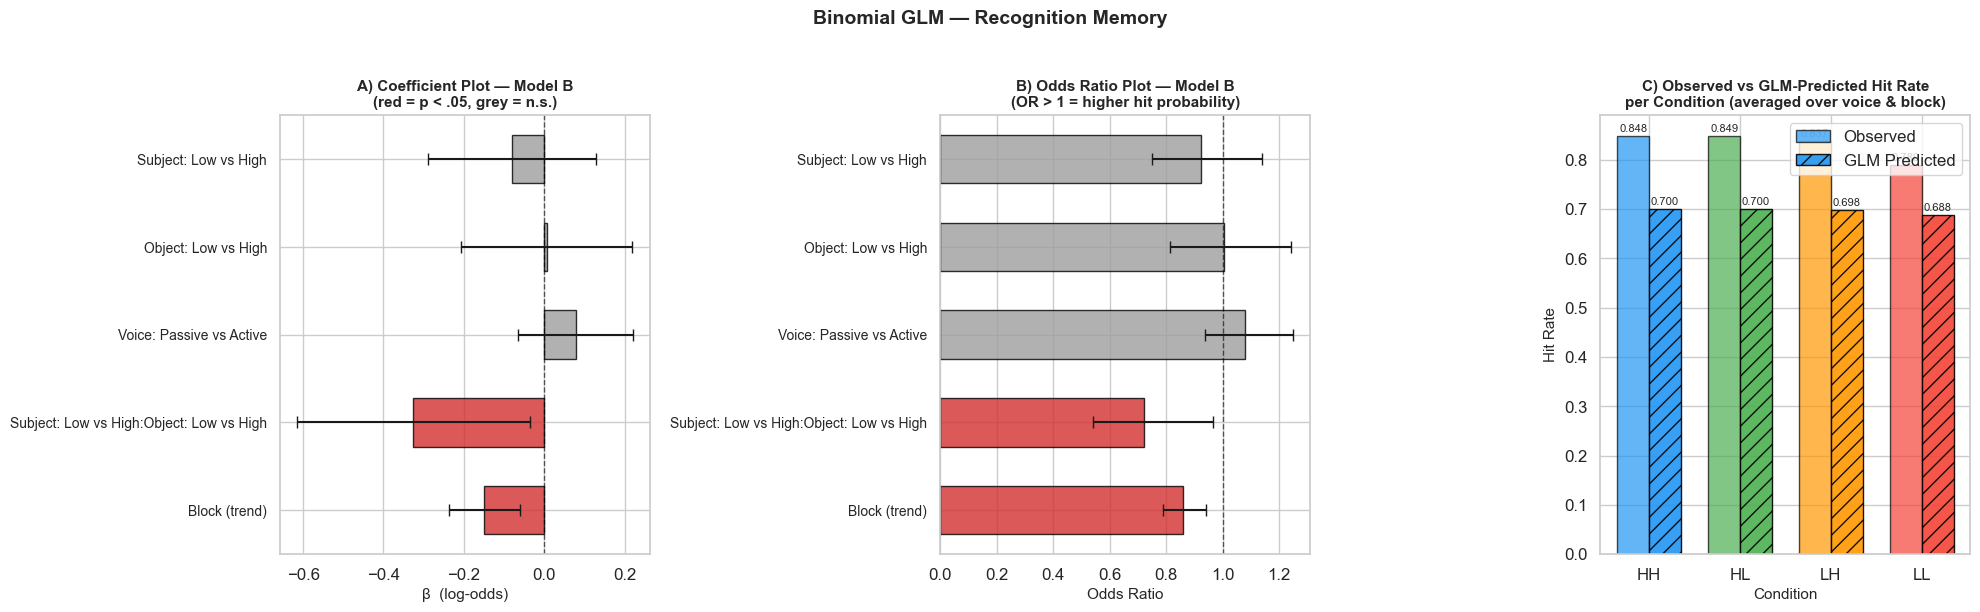

In [ ]:

import statsmodels.api as sm
from patsy import dmatrices
from scipy.stats import chi2 as chi2_dist
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ══════════════════════════════════════════════════════════════════════════════
# 1. BUILD GLM DATASET
#    Outcome: corrected memorability score = hit_rate − fa_rate  (continuous)
#    Unit: participant × condition × voice × block
#    FA rate is per participant (global), same value across all their cells.
# ══════════════════════════════════════════════════════════════════════════════
_key = ['pid', 'condition', 'voice_label', 'block']

_tgt = (df_valid[(df_valid['Event'] == 'Sentence shown') &
                  df_valid['is_repeat'] & ~df_valid['is_validation']]
        .copy())
_tgt['condition'] = _tgt['stim_prefix'].map(COND_MAP)

_hits = (df_valid[(df_valid['Event'] == 'IR pressed') &
                   df_valid['is_repeat'] & ~df_valid['is_validation'] &
                   (df_valid['Accuracy IR'] == 1)]
         .copy())
_hits['condition'] = _hits['stim_prefix'].map(COND_MAP)

tgt_cnt = (_tgt.dropna(subset=['condition', 'voice_label'])
           .groupby(_key).size().reset_index(name='n_shown'))
hit_cnt = (_hits.dropna(subset=['condition', 'voice_label'])
           .groupby(_key).size().reset_index(name='n_hits'))

glm_df = tgt_cnt.merge(hit_cnt, on=_key, how='left')
glm_df['n_hits']   = glm_df['n_hits'].fillna(0).astype(int)
glm_df['hit_rate'] = glm_df['n_hits'] / glm_df['n_shown']

# Attach per-participant FA rate — the same for all rows of that participant
glm_df = glm_df.merge(fa_df[['pid', 'fa_rate']], on='pid', how='left')
glm_df['corrected_score'] = glm_df['hit_rate'] - glm_df['fa_rate']

# Encode factors (reference level: High for mem, Active for voice)
glm_df['subject_mem'] = pd.Categorical(glm_df['condition'].map(SUBJ_MEMO),
                                        categories=['High', 'Low'])
glm_df['object_mem']  = pd.Categorical(glm_df['condition'].map(OBJ_MEMO),
                                        categories=['High', 'Low'])
glm_df['voice_cat']   = pd.Categorical(glm_df['voice_label'],
                                        categories=['Active', 'Passive'])
glm_df['block_num']   = glm_df['block'] + 1   # 1 / 2 / 3

glm_df = (glm_df[glm_df['n_shown'] > 0]
          .dropna(subset=['corrected_score'])
          .reset_index(drop=True))

print(f"GLM dataset: {len(glm_df)} cells  |  "
      f"{glm_df['pid'].nunique()} participants")
print(f"Corrected score range: "
      f"[{glm_df['corrected_score'].min():.3f}, {glm_df['corrected_score'].max():.3f}]  "
      f"mean = {glm_df['corrected_score'].mean():.3f}")
print(glm_df[['condition', 'voice_cat', 'block_num',
              'hit_rate', 'fa_rate', 'corrected_score']].head(8).to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# 2. FIT GAUSSIAN GLM  (identity link = ordinary linear regression)
#    Outcome is continuous corrected_score; Gaussian family is the right choice.
# ══════════════════════════════════════════════════════════════════════════════
_, X_main = dmatrices(
    "corrected_score ~ subject_mem + object_mem + voice_cat + block_num",
    data=glm_df, return_type='dataframe')
glm_main = sm.GLM(glm_df['corrected_score'], X_main,
                   family=sm.families.Gaussian()).fit()

_, X_full = dmatrices(
    "corrected_score ~ subject_mem * object_mem + voice_cat + block_num",
    data=glm_df, return_type='dataframe')
glm_full = sm.GLM(glm_df['corrected_score'], X_full,
                   family=sm.families.Gaussian()).fit()

# ══════════════════════════════════════════════════════════════════════════════
# 3. MODEL SUMMARIES
# ══════════════════════════════════════════════════════════════════════════════
y     = glm_df['corrected_score'].values
ss_tot = np.sum((y - y.mean()) ** 2)

for lbl, model in [("MODEL A — Main Effects Only", glm_main),
                    ("MODEL B — Main Effects + Subject × Object Interaction", glm_full)]:
    print("\n" + "=" * 70)
    print(lbl)
    print("=" * 70)
    ci = model.conf_int()
    coef_tbl = pd.DataFrame({
        'β (corrected score)': model.params,
        'SE':                  model.bse,
        't':                   model.tvalues,
        'p-value':             model.pvalues,
        '95% CI lower':        ci[0],
        '95% CI upper':        ci[1],
    }).round(4)
    coef_tbl['sig'] = coef_tbl['p-value'].apply(
        lambda p: '***' if p < .001 else ('**' if p < .01 else ('*' if p < .05 else '')))
    display(coef_tbl)
    ss_res = np.sum((y - model.fittedvalues.values) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f"  AIC = {model.aic:.2f}   |   log-likelihood = {model.llf:.2f}   |   R² = {r2:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. LIKELIHOOD-RATIO TEST  (Model A vs Model B)
# ══════════════════════════════════════════════════════════════════════════════
lrt_stat = 2 * (glm_full.llf - glm_main.llf)
lrt_df   = int(glm_full.df_model - glm_main.df_model)
lrt_p    = chi2_dist.sf(lrt_stat, lrt_df)

print("\n" + "=" * 70)
print("LIKELIHOOD-RATIO TEST:  Model A (no interaction) vs Model B (interaction)")
print("=" * 70)
print(f"  LRT χ²({lrt_df}) = {lrt_stat:.4f},  p = {lrt_p:.4f}")
print(f"  AIC  Model A = {glm_main.aic:.2f}   Model B = {glm_full.aic:.2f}")
if lrt_p < 0.05:
    print("  ★ Interaction significantly improves fit → Subject × Object interaction present.")
else:
    print("  ✗ Interaction does NOT improve fit → additive (main-effects) model preferred.")

# ══════════════════════════════════════════════════════════════════════════════
# 5. MARGINAL PREDICTED CORRECTED SCORES per CONDITION
# ══════════════════════════════════════════════════════════════════════════════
pred_df = glm_df.copy()
pred_df['predicted'] = glm_full.fittedvalues.values

marginal = (pred_df.groupby('condition')
            .agg(obs_mean=('corrected_score', 'mean'),
                 pred_mean=('predicted',       'mean'))
            .loc[cond_order])
print("\nMarginal predicted vs observed corrected score per condition (Model B):")
display(marginal.round(4))

# ══════════════════════════════════════════════════════════════════════════════
# 6. VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
glm_palette = {'HH': '#2196F3', 'HL': '#4CAF50', 'LH': '#FF9800', 'LL': '#F44336'}
best_model  = glm_full

def _make_labels(terms):
    return (terms
            .str.replace(r"subject_mem\[T\.Low\]", "Subject: Low vs High",     regex=True)
            .str.replace(r"object_mem\[T\.Low\]",  "Object: Low vs High",      regex=True)
            .str.replace(r"voice_cat\[T\.Passive\]","Voice: Passive vs Active", regex=True)
            .str.replace("block_num",               "Block (trend)",            regex=False)
            .str.replace(r"subject_mem\[T\.Low\]:object_mem\[T\.Low\]",
                         "Subject Low × Object Low", regex=True))

# ── A) Coefficient Forest Plot ────────────────────────────────────────────────
ax = axes[0]
ci_fm = best_model.conf_int()
cp = pd.DataFrame({
    'term': best_model.params.index[1:],
    'beta': best_model.params.values[1:],
    'lo':   ci_fm[0].values[1:],
    'hi':   ci_fm[1].values[1:],
    'p':    best_model.pvalues.values[1:],
}).iloc[::-1].reset_index(drop=True)

cp_colors = ['#D32F2F' if p < 0.05 else '#9E9E9E' for p in cp['p']]
y_pos = np.arange(len(cp))
ax.barh(y_pos, cp['beta'],
        xerr=[cp['beta'] - cp['lo'], cp['hi'] - cp['beta']],
        color=cp_colors, edgecolor='black', alpha=0.8, height=0.55, capsize=4)
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(_make_labels(cp['term']), fontsize=10)
ax.set_xlabel('β  (corrected score units)', fontsize=11)
ax.set_title('A) Coefficient Plot — Model B\n(red = p < .05, grey = n.s.)',
             fontsize=11, fontweight='bold')

# ── B) Observed vs Predicted scatter (all cells) ─────────────────────────────
ax = axes[1]
for cond in cond_order:
    sub = pred_df[pred_df['condition'] == cond]
    ax.scatter(sub['corrected_score'], sub['predicted'],
               color=glm_palette[cond], alpha=0.4, s=20, label=cond)
lims = [min(pred_df['corrected_score'].min(), pred_df['predicted'].min()) - 0.03,
        max(pred_df['corrected_score'].max(), pred_df['predicted'].max()) + 0.03]
ax.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.6, label='Perfect fit')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Observed Corrected Score', fontsize=11)
ax.set_ylabel('GLM Predicted Corrected Score', fontsize=11)
ax.set_title('B) Observed vs Predicted\n(all cells, coloured by condition)',
             fontsize=11, fontweight='bold')
ax.legend(title='Condition', fontsize=9)

# ── C) Marginal: Observed vs Predicted per Condition ─────────────────────────
ax = axes[2]
x = np.arange(len(cond_order))
width = 0.35
bars_obs  = ax.bar(x - width/2, marginal['obs_mean'],  width,
                   label='Observed', edgecolor='black', alpha=0.7,
                   color=[glm_palette[c] for c in cond_order])
bars_pred = ax.bar(x + width/2, marginal['pred_mean'], width,
                   label='GLM Predicted', edgecolor='black', alpha=0.9,
                   color=[glm_palette[c] for c in cond_order], hatch='//')
for bar, val in zip(bars_obs,  marginal['obs_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars_pred, marginal['pred_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(cond_order)
ax.set_xlabel('Condition', fontsize=11)
ax.set_ylabel('Corrected Memorability Score', fontsize=11)
ax.set_title('C) Marginal Observed vs Predicted\nCorrected Score per Condition',
             fontsize=11, fontweight='bold')
ax.legend()

plt.suptitle('Gaussian GLM — Corrected Memorability Score (HR − FAR)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
